# Transfer learning, recall de "enfermo" y explicabilidad ampliada — Mandioca (v3)

**Proyecto:** IC522 — Trabajo Final Integrador · **Alumno:** WLODECK, Fabricio Joaquín
**Archivo:** `02_transfer_learning_mandioca_v3_recall_enfermo.ipynb` — **complementa** (no reemplaza) a
`02_transfer_learning_mandioca.ipynb` (v1) y `02b_transfer_learning_mandioca_v2.ipynb` (v2).

## Por qué esta versión (motivación)

La prioridad del proyecto es **no confundir una hoja enferma (CBB/CBSD/CGM/CMD) con una sana**: un
falso negativo (enfermo → sano) es mucho más costoso que un falso positivo (sano → enfermo), porque
una planta enferma no tratada propaga la enfermedad. El **macro-F1** usado en la v1 pesa igual todos
los errores entre las 5 clases y no fija ningún límite a los falsos negativos; además, un **F2 binario
enfermo-vs-sano** es casi inútil aquí porque el dataset es ~80-89 % enfermo: un clasificador trivial que
dijera "siempre enfermo" ya sacaría F2 ≈ 0,95-0,98.

**Métrica adoptada (estándar en tamizaje clínico):**

1. **Restricción dura:** sensibilidad (recall) de la clase agregada "enfermo" ≥ **0,97**, ajustada con un
   umbral τ sobre `p(sano)` calculado en **validación** (se predice "sano" solo si `p(sano) ≥ τ`; si no,
   gana la enfermedad más probable de las 4).
2. **Selección entre modelos que cumplen la restricción:** **macro-F1** (así se sigue premiando distinguir
   las 5 clases, no solo "enfermo vs sano").
3. Se reportan además, para contexto, las métricas clásicas: accuracy, balanced accuracy, precision/recall/F1
   macro y weighted, y por clase — pero **no** se usan para elegir el modelo final.

## Qué hace este notebook

1. **Datos** — mismo 20 % que la v1 (`manifest_20pct.csv`, reutilizado) **menos los outliers "no-hoja"
   de la red 2** (298 imágenes, ver `datos\cambios 02 - prueba volumen outliers\`) + una variante **25 %**
   con el mismo val/test y train ampliado.
2. **Embeddings cacheados** de **7 backbones**: MobileNetV2, EfficientNet-B7, ResNet50, DenseNet121,
   VGG16, EfficientNet-B0, MobileNetV3-Small. Con backbone congelado y **sin aumento de datos**, entrenar
   la cabeza sobre estos embeddings es equivalente a pasar la red en cada época — permite comparar 7
   backbones sin pagar 7× el costo de cómputo de la v1.
3. **Transfer learning (cabeza)** sobre MV2 y B7 en 20 % y 25 %, con el umbral τ ajustado en val.
4. **Fine-tuning completo de MV2** (30 % del backbone) en 20 % y 25 %, antes/después explícito.
5. **Clasificadores clásicos** (RandomForest, SVM, XGBoost, MLP) sobre los 7 backbones × 2 fracciones.
6. **LIME** — por cada modelo (antes y después del FT) y cada clase: **4 aciertos + 4 errores**, con el
   texto explícito de qué predijo cada modelo y por qué probabilidad, priorizando los errores
   enfermo→sano.
7. **Tiempos** de cada etapa (datos, embeddings, entrenamiento, clásicos, inferencia, LIME) registrados
   en `reportes\v3\tiempos_v3.md`.
8. **Consolidado** final en `reportes\v3\resultados_v3.csv` + tabla Markdown.

Todo nuevo vive en `modelos\v3\` y `reportes\v3\`. **No se modifica nada de la v1/v2.**


## Fase 0 — Entorno, semillas y configuración

In [1]:
import os, sys, json, time, random, math, warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import timm
from torchvision import transforms as T

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (f1_score, precision_score, recall_score, accuracy_score,
                             balanced_accuracy_score, confusion_matrix, classification_report)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

SMOKE = os.environ.get("SMOKE", "0") == "1"
TAG = "_smoke" if SMOKE else ""

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

print("torch:", torch.__version__, "| timm:", timm.__version__)
print("device:", DEVICE, "-", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
print("modo SMOKE:", SMOKE)

# ---- Cronometro global: registra TODAS las etapas (entrenamiento + inferencia) ----
TIEMPOS = []  # lista de dicts: etapa, detalle, backbone, fraccion, n_imgs, segundos, ms_por_img

class Cronometro:
    def __init__(self, etapa, detalle="", backbone="", fraccion="", n_imgs=None):
        self.etapa, self.detalle, self.backbone, self.fraccion, self.n_imgs = etapa, detalle, backbone, fraccion, n_imgs
    def __enter__(self):
        self.t0 = time.time()
        return self
    def __exit__(self, *exc):
        dt = time.time() - self.t0
        ms_img = (dt * 1000.0 / self.n_imgs) if self.n_imgs else None
        TIEMPOS.append(dict(etapa=self.etapa, detalle=self.detalle, backbone=self.backbone,
                            fraccion=self.fraccion, n_imgs=self.n_imgs,
                            segundos=round(dt, 3), ms_por_img=round(ms_img, 4) if ms_img else None))
        print(f"[tiempo] {self.etapa} | {self.detalle}: {dt:.2f} s" +
              (f" ({ms_img:.3f} ms/img)" if ms_img else ""))

print("Cronometro listo. Registros acumulados en TIEMPOS (se exportan en la Fase 8).")


D:\final_inteligencia\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch: 2.14.0+cu126 | timm: 1.0.30
device: cuda - NVIDIA GeForce GTX 1660 SUPER
modo SMOKE: True
Cronometro listo. Registros acumulados en TIEMPOS (se exportan en la Fase 8).


In [2]:
BASE = Path("D:/final_inteligencia")
DIR_IMG = BASE / "datos" / "cambios 01 - no hojas" / "imagenes filtradas"
DIR_LABELS = BASE / "datos" / "cambios 01 - no hojas" / "labels_filtrado.csv"
DIR_OUTLIERS2 = BASE / "datos" / "cambios 02 - prueba volumen outliers" / "labels_outliers_prueba.csv"
DIR_SPLIT = BASE / "datos" / "splits"
MANIFEST_V1 = DIR_SPLIT / "manifest_20pct.csv"
DIR_MODEL = BASE / "modelos"
DIR_V3 = DIR_MODEL / "v3"
DIR_REPORT = BASE / "reportes" / "v3"
DIR_LIME = DIR_REPORT / "lime"
for d in (DIR_V3, DIR_REPORT, DIR_LIME):
    d.mkdir(parents=True, exist_ok=True)

SEED = 42
CLASS_NAMES = ["cbb", "cbsd", "cgm", "cmd", "healthy"]
NUM_CLASSES = 5
HEALTHY_IDX = 4
MEAN, STD = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)
RECALL_OBJ = 0.97   # sensibilidad minima exigida para la clase "enfermo" (ajustada en val)
MAX_TEST_PC = 60
FRAC_25_EXTRA = 0.05   # 20% -> 25%: se agrega este % adicional de train, estratificado

# backbones para embeddings + TL de cabeza + clasicos
BACKBONES = {
    "mobilenetv2":    dict(name="mobilenetv2_100",            size=224),
    "efficientnet_b7": dict(name="tf_efficientnet_b7.ra_in1k", size=600),
    "resnet50":       dict(name="resnet50.a1_in1k",           size=224),
    "densenet121":    dict(name="densenet121.ra_in1k",        size=224),
    "vgg16":          dict(name="vgg16.tv_in1k",               size=224),
    "efficientnet_b0": dict(name="efficientnet_b0.ra_in1k",    size=224),
    "mobilenetv3_small": dict(name="mobilenetv3_small_100.lamb_in1k", size=224),
}

CONFIG_TL = {
    "mobilenetv2":     dict(epochs=25, lr=1e-3, patience=5, batch=64),
    "efficientnet_b7": dict(epochs=20, lr=1e-3, patience=5, batch=64),
}
FT_CFG = dict(epochs=12, lr=1e-4, patience=3, unfreeze=0.30, batch=32, size=224,
              backbone="mobilenetv2_100")

LIME_SAMPLES = 800
LIME_ACIERTOS = 4
LIME_ERRORES = 4

if SMOKE:
    for k in CONFIG_TL:
        CONFIG_TL[k].update(epochs=2, patience=1)
    FT_CFG.update(epochs=2, patience=1)
    LIME_SAMPLES, LIME_ACIERTOS, LIME_ERRORES = 60, 1, 1

print("Backbones:", list(BACKBONES.keys()))
print("CONFIG_TL:", json.dumps(CONFIG_TL, indent=1))
print("FT_CFG:", FT_CFG)
print(f"Objetivo recall enfermo = {RECALL_OBJ} | LIME samples={LIME_SAMPLES} (acierto={LIME_ACIERTOS}, error={LIME_ERRORES})")


Backbones: ['mobilenetv2', 'efficientnet_b7', 'resnet50', 'densenet121', 'vgg16', 'efficientnet_b0', 'mobilenetv3_small']
CONFIG_TL: {
 "mobilenetv2": {
  "epochs": 2,
  "lr": 0.001,
  "patience": 1,
  "batch": 64
 },
 "efficientnet_b7": {
  "epochs": 2,
  "lr": 0.001,
  "patience": 1,
  "batch": 64
 }
}
FT_CFG: {'epochs': 2, 'lr': 0.0001, 'patience': 1, 'unfreeze': 0.3, 'batch': 32, 'size': 224, 'backbone': 'mobilenetv2_100'}
Objetivo recall enfermo = 0.97 | LIME samples=60 (acierto=1, error=1)


## Fase 1 — Datos: exclusión de outliers "no-hoja" (red 2) y subsets 20 % / 25 %

* **Exclusión adicional:** además de las 33 imágenes "no-hoja" ya filtradas en `imagenes filtradas/`
  (base del EDA 01), se excluyen las **298 imágenes de la red 2** (`datos\cambios 02 - prueba volumen
  outliers\labels_outliers_prueba.csv`, columna `flag_red2 | flag_base`) — raíces, tubérculos cortados,
  palos y fotos de fondo/tierra/neutro dominante que no aportan al diagnóstico foliar.
* **20 %:** se parte de `manifest_20pct.csv` (v1, mismo split, semilla 42) y se quitan las imágenes
  marcadas por la red 2. Si alguna clase del test balanceado (60/clase) queda por debajo de 60 tras el
  filtro, se repone desde `test_pool_rest` de la misma clase (mismo criterio de estratificación).
* **25 %:** se parte del mismo val y test de la rama 20 % (sin tocarlos) y se agrega a train un **5 %
  adicional** del dataset limpio, muestreado de `out_subset` y estratificado por clase × fuente — así
  val/test quedan **idénticos** entre 20 % y 25 %, y la única diferencia es el tamaño de train.


In [3]:
df_lab = pd.read_csv(DIR_LABELS)
df_lab["label_name"] = df_lab["label"].map(dict(enumerate(CLASS_NAMES)))
assert len(df_lab) == 26304 and df_lab["image_id"].is_unique

met2 = pd.read_csv(DIR_OUTLIERS2, usecols=["image_id", "flag_base", "flag_red2"])
ids_red2 = set(met2.loc[met2["flag_base"] | met2["flag_red2"], "image_id"])
print(f"Imagenes marcadas red2 (union con base): {len(ids_red2):,}")

man_v1 = pd.read_csv(MANIFEST_V1)
assert man_v1["image_id"].is_unique
n_antes = len(man_v1)
man_v1["es_outlier_red2"] = man_v1["image_id"].isin(ids_red2)
print("De las del manifest v1, cuantas caen en la red2 por split:")
print(man_v1.groupby("split")["es_outlier_red2"].sum().to_string())

# se excluyen del split activo (pasan a out_subset); nunca se tocan los csv originales
man = man_v1.copy()
man.loc[man["es_outlier_red2"] & (man["split"] != "out_subset"), "split"] = "out_subset"
man = man.drop(columns="es_outlier_red2")
print(f"\nmanifest v1 original: {n_antes:,} filas | tras excluir red2 quedan activas "
      f"{(man['split'] != 'out_subset').sum():,} (antes {(man_v1['split'] != 'out_subset').sum():,})")


Imagenes marcadas red2 (union con base): 298
De las del manifest v1, cuantas caen en la red2 por split:
split
out_subset        215
test                2
test_pool_rest      9
train              31
val                 8

manifest v1 original: 26,304 filas | tras excluir red2 quedan activas 5,210 (antes 5,260)


In [4]:
# Reponer el test balanceado a 60/clase si quedo corto tras excluir red2
pool_rest = man[man["split"] == "test_pool_rest"]
faltan = {}
for i, cname in enumerate(CLASS_NAMES):
    n_test = int((man.loc[man["split"] == "test", "label"] == i).sum())
    if n_test < MAX_TEST_PC:
        faltan[i] = MAX_TEST_PC - n_test
print("Faltantes en test por clase:", {CLASS_NAMES[k]: v for k, v in faltan.items()} or "ninguno")

rng = np.random.RandomState(SEED)
for i, n_falt in faltan.items():
    candidatos = pool_rest[pool_rest["label"] == i]
    candidatos = candidatos[~candidatos["image_id"].isin(ids_red2)]
    elegidos = candidatos.sample(n=min(n_falt, len(candidatos)), random_state=SEED).index
    man.loc[elegidos, "split"] = "test"

tc = man.loc[man["split"] == "test", "label"].value_counts().sort_index()
print("\ntest balanceado final (por clase):")
print(tc.to_string())
assert (tc == MAX_TEST_PC).all(), "no se pudo reponer el test balanceado a 60/clase"

s_tr = set(man[man.split == "train"]["image_id"]); s_va = set(man[man.split == "val"]["image_id"])
s_te = set(man[man.split == "test"]["image_id"])
assert s_tr.isdisjoint(s_va) and s_tr.isdisjoint(s_te) and s_va.isdisjoint(s_te)
assert len(s_tr & ids_red2) == 0 and len(s_va & ids_red2) == 0 and len(s_te & ids_red2) == 0
print("OK: sin fuga | sin outliers red2 en train/val/test")

MANIFEST_20 = DIR_SPLIT / "manifest_v3_20pct.csv"
if not SMOKE:
    man.to_csv(MANIFEST_20, index=False)
    print("guardado:", MANIFEST_20, "| train =", (man.split == "train").sum(),
          "val =", (man.split == "val").sum(), "test =", (man.split == "test").sum())
else:
    print("SMOKE: manifest_v3_20pct NO se sobreescribe (solo en memoria)")


Faltantes en test por clase:

 {'cgm': 1, 'healthy': 1}



test balanceado final (por clase):
label
0    60
1    60
2    60
3    60
4    60
OK: sin fuga | sin outliers red2 en train/val/test
SMOKE: manifest_v3_20pct NO se sobreescribe (solo en memoria)


In [5]:
# Rama 25%: mismo val/test, train ampliado con FRAC_25_EXTRA del pool out_subset (estratificado)
man25 = man.copy()
out_pool = man25[(man25["split"] == "out_subset") & (~man25["image_id"].isin(ids_red2))].copy()
strata_out = out_pool["label"].astype(str) + "_" + out_pool["source"].astype(str)

n_extra_total = int(round(FRAC_25_EXTRA * len(df_lab)))
n_extra_total = min(n_extra_total, len(out_pool) - 1)
extra_idx, _ = train_test_split(out_pool.index, train_size=n_extra_total,
                                stratify=strata_out, random_state=SEED)
man25.loc[extra_idx, "split"] = "train"

print("25% -> train:", (man25.split == "train").sum(), "(20% tenia", (man.split == "train").sum(), ")")
print("val/test identicos a la rama 20%:",
      (man25.loc[man25.split=='val','image_id'].sort_values().values ==
       man.loc[man.split=='val','image_id'].sort_values().values).all(),
      (man25.loc[man25.split=='test','image_id'].sort_values().values ==
       man.loc[man.split=='test','image_id'].sort_values().values).all())

MANIFEST_25 = DIR_SPLIT / "manifest_v3_25pct.csv"
if not SMOKE:
    man25.to_csv(MANIFEST_25, index=False)
    print("guardado:", MANIFEST_25)
else:
    print("SMOKE: manifest_v3_25pct NO se sobreescribe (solo en memoria)")

MANIFESTS = {"20pct": man, "25pct": man25}
total_dataset = len(df_lab)
for frac, m in MANIFESTS.items():
    n_tr, n_va, n_te = (m.split=="train").sum(), (m.split=="val").sum(), (m.split=="test").sum()
    print(f"{frac}: train={n_tr} ({100*n_tr/total_dataset:.1f}%) val={n_va} test={n_te} "
          f"total_activo={n_tr+n_va+n_te} ({100*(n_tr+n_va+n_te)/total_dataset:.1f}% del dataset limpio)")


25% -> train:

 4650 (20% tenia 3335 )
val/test identicos a la rama 20%: True True
SMOKE: manifest_v3_25pct NO se sobreescribe (solo en memoria)
20pct: train=3335 (12.7%) val=834 test=300 total_activo=4469 (17.0% del dataset limpio)
25pct: train=4650 (17.7%) val=834 test=300 total_activo=5784 (22.0% del dataset limpio)


In [6]:
# SMOKE: reduccion en memoria a pocos datos por clase para validar TODO el flujo rapido.
# NO toca los manifiestos en disco (la guardada de arriba ya quedo anulada en modo smoke).
if SMOKE:
    SMOKE_N = {"train": 8, "val": 4, "test": 4}
    for frac, m in MANIFESTS.items():
        for sp, n in SMOKE_N.items():
            sub = m[m.split == sp]
            keep = set(sub.groupby("label", group_keys=False).head(n).index)
            m.loc[sub.index.difference(keep), "split"] = "out_subset"
        print(f"SMOKE {frac}: train={(m.split=='train').sum()} val={(m.split=='val').sum()} "
              f"test={(m.split=='test').sum()}")
    tc = man.loc[man.split == "test", "label"].value_counts().sort_index()
    assert len(tc) == NUM_CLASSES and (tc == SMOKE_N["test"]).all(), "SMOKE: test reducido mal"
    s_tr = set(man[man.split == "train"]["image_id"]); s_va = set(man[man.split == "val"]["image_id"])
    s_te = set(man[man.split == "test"]["image_id"])
    assert s_tr.isdisjoint(s_va) and s_tr.isdisjoint(s_te) and s_va.isdisjoint(s_te)
    print("SMOKE: reduccion aplicada en memoria, sin fuga de splits")


SMOKE 20pct: train=40 val=20 test=20
SMOKE 25pct: train=40 val=20 test=20
SMOKE: reduccion aplicada en memoria, sin fuga de splits


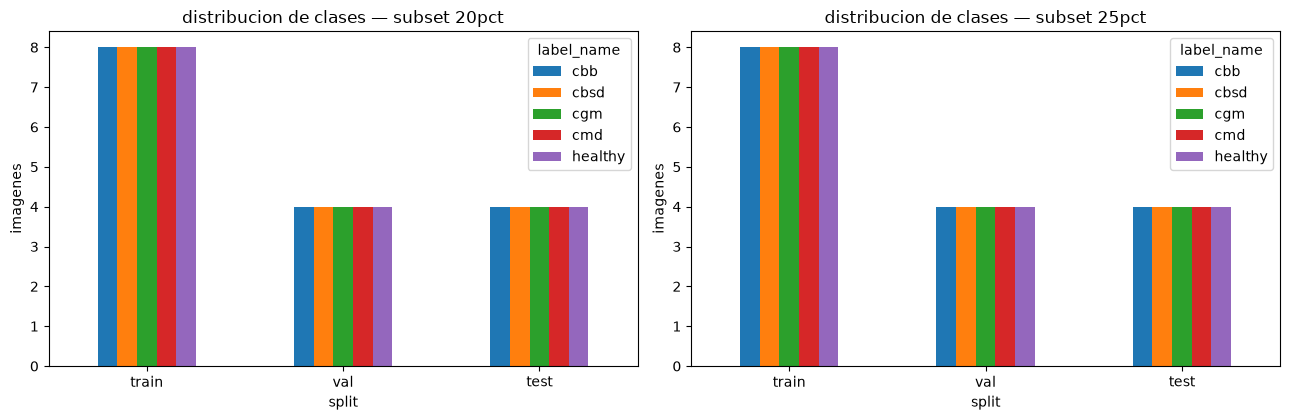

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
for ax, (frac, m) in zip(axes, MANIFESTS.items()):
    ct = m[m.split.isin(["train","val","test"])].groupby(["label_name","split"]).size().unstack(0)
    ct = ct.reindex(["train","val","test"])[CLASS_NAMES]
    ct.plot(kind="bar", ax=ax, rot=0)
    ax.set_title(f"distribucion de clases — subset {frac}")
    ax.set_ylabel("imagenes")
plt.tight_layout(); plt.show()


## Fase 2 — Métricas: umbral τ para recall de "enfermo" ≥ 0,97 + métricas clásicas

* **`buscar_umbral_tau`**: sobre las probabilidades de **validación**, recorre τ de 1,0 a 0,0 y elige el
  **mayor τ** tal que la sensibilidad de "enfermo" (= 1 − tasa de FN enfermo→sano) sea ≥ `RECALL_OBJ`.
  Si ningún τ alcanza el objetivo, se usa τ = 0 (nunca predecir "sano": sensibilidad = 1 por construcción).
* **Regla de decisión con τ**: `pred = "sano"` si `p(sano) ≥ τ`; si no, `pred = argmax` de las 4 clases
  enfermas. Esto es intencionalmente **asimétrico**: solo se exige confianza alta para decir "sano".
* **`metricas_completas`**: devuelve accuracy, balanced accuracy, precision/recall/F1 macro y weighted,
  F1 por clase, matriz de confusión, y el bloque específico enfermo-vs-sano (sensibilidad, especificidad,
  FN por clase enferma, precisión de "sano" = NPV).
* La **selección de modelos** (mejor época, mejor backbone, mejor clasificador) se hace en dos pasos:
  1. filtrar los que cumplen sensibilidad-enfermo ≥ `RECALL_OBJ` en val (con su propio τ);
  2. entre esos, elegir el de mayor **macro-F1** en val (también con τ aplicado).


In [8]:
def buscar_umbral_tau(y_true, prob_sano, objetivo=RECALL_OBJ):
    """Mayor tau en [0,1] tal que sensibilidad(enfermo) >= objetivo. Se evalua sobre los
    valores unicos de prob_sano (los umbrales optimos siempre caen ahi)."""
    y_true = np.asarray(y_true)
    es_enfermo = y_true != HEALTHY_IDX
    n_enfermo = int(es_enfermo.sum())
    candidatos = np.unique(np.concatenate([[0.0, 1.0], prob_sano]))[::-1]
    mejor_tau = 0.0
    for tau in candidatos:
        pred_sano = prob_sano >= tau
        fn = int((pred_sano & es_enfermo).sum())
        sens = 1.0 - fn / max(1, n_enfermo)
        if sens >= objetivo:
            mejor_tau = float(tau)
            break
    return mejor_tau


def aplicar_tau(prob, tau):
    """prob: [N,5] softmax. Devuelve y_pred aplicando la regla asimetrica con el umbral tau."""
    prob = np.asarray(prob)
    prob_sano = prob[:, HEALTHY_IDX]
    pred_enfermo = prob[:, :HEALTHY_IDX].argmax(axis=1)
    y_pred = np.where(prob_sano >= tau, HEALTHY_IDX, pred_enfermo)
    return y_pred


def metricas_enfermo_sano(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    es_enfermo = y_true != HEALTHY_IDX
    es_sano = ~es_enfermo
    pred_enfermo = y_pred != HEALTHY_IDX
    pred_sano = ~pred_enfermo
    tp = int((es_enfermo & pred_enfermo).sum())    # enfermo detectado como enfermo
    fn = int((es_enfermo & pred_sano).sum())       # ENFERMO -> SANO (el error critico)
    tn = int((es_sano & pred_sano).sum())          # sano detectado como sano
    fp = int((es_sano & pred_enfermo).sum())       # sano -> enfermo (falsa alarma, barato)
    sens = tp / max(1, tp + fn)
    spec = tn / max(1, tn + fp)
    npv = tn / max(1, tn + fn)     # precision de "sano"
    fn_por_clase = {CLASS_NAMES[c]: int(((y_true == c) & pred_sano).sum())
                    for c in range(NUM_CLASSES) if c != HEALTHY_IDX}
    return dict(sensibilidad_enfermo=round(sens, 4), especificidad_sano=round(spec, 4),
                vpn_sano=round(npv, 4), tp=tp, fn=fn, tn=tn, fp=fp,
                fn_por_clase_enferma=fn_por_clase)


def metricas_completas(y_true, y_pred, y_prob=None):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    per_f1 = f1_score(y_true, y_pred, average=None, labels=np.arange(NUM_CLASSES), zero_division=0)
    per_p = precision_score(y_true, y_pred, average=None, labels=np.arange(NUM_CLASSES), zero_division=0)
    per_r = recall_score(y_true, y_pred, average=None, labels=np.arange(NUM_CLASSES), zero_division=0)
    out = dict(
        accuracy=float(accuracy_score(y_true, y_pred)),
        balanced_acc=float(balanced_accuracy_score(y_true, y_pred)),
        f1_macro=float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        f1_weighted=float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
        precision_macro=float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
        precision_weighted=float(precision_score(y_true, y_pred, average="weighted", zero_division=0)),
        recall_macro=float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
        recall_weighted=float(recall_score(y_true, y_pred, average="weighted", zero_division=0)),
        f1_per_class=[float(v) for v in per_f1],
        precision_per_class=[float(v) for v in per_p],
        recall_per_class=[float(v) for v in per_r],
        y_true=y_true.tolist(), y_pred=y_pred.tolist(),
    )
    out.update(metricas_enfermo_sano(y_true, y_pred))
    if y_prob is not None:
        out["y_prob"] = np.asarray(y_prob).round(5).tolist()
    return out


def evaluar_con_tau(y_val, prob_val, y_test, prob_test, objetivo=RECALL_OBJ):
    """Ajusta tau en val y evalua val/test con la regla asimetrica. Devuelve dict con 'tau',
    'val' y 'test' (cada uno = metricas_completas)."""
    tau = buscar_umbral_tau(y_val, np.asarray(prob_val)[:, HEALTHY_IDX], objetivo)
    pred_val = aplicar_tau(prob_val, tau)
    pred_test = aplicar_tau(prob_test, tau)
    return dict(tau=tau,
               val=metricas_completas(y_val, pred_val, prob_val),
               test=metricas_completas(y_test, pred_test, prob_test),
               val_argmax=metricas_completas(y_val, np.asarray(prob_val).argmax(1), prob_val),
               test_argmax=metricas_completas(y_test, np.asarray(prob_test).argmax(1), prob_test))


def cumple_objetivo(res, objetivo=RECALL_OBJ):
    return res["val"]["sensibilidad_enfermo"] >= objetivo - 1e-9


def elegir_mejor(resultados, objetivo=RECALL_OBJ):
    """resultados: dict id -> res (de evaluar_con_tau). Filtra por sensibilidad val >= objetivo y
    dentro de esos elige el de mayor f1_macro en val. Si ninguno cumple, el de mayor sensibilidad."""
    ok = {k: v for k, v in resultados.items() if cumple_objetivo(v, objetivo)}
    universo = ok if ok else resultados
    mejor_id = max(universo, key=lambda k: (universo[k]["val"]["f1_macro"]))
    return mejor_id, bool(ok)

print("Fase 2 (metricas) lista: buscar_umbral_tau, aplicar_tau, metricas_completas, evaluar_con_tau, elegir_mejor")


Fase 2 (metricas) lista: buscar_umbral_tau, aplicar_tau, metricas_completas, evaluar_con_tau, elegir_mejor


## Fase 3 — Embeddings cacheados de 7 backbones (sin aumento de datos)

**Por qué cachear:** con el backbone **congelado** y **sin aumento de datos**, el embedding GAP de una
imagen es siempre el mismo número — entrenar una cabeza lineal/MLP sobre ese embedding es
**matemáticamente equivalente** a pasar la imagen por la red completa en cada época, pero mucho más
rápido (la v1 tardó 74-131 min por corrida de EfficientNet-B7; acá se paga el costo de pasar por B7
**una sola vez** por imagen y división, y el resto es casi instantáneo).

Backbones: **MobileNetV2, EfficientNet-B7, ResNet50, DenseNet121, VGG16, EfficientNet-B0,
MobileNetV3-Small** (pesos ImageNet, `timm`). Los embeddings se cachean por `image_id` en
`modelos\v3\emb_{backbone}.npz` y se reutilizan entre la rama 20 % y 25 % (solo cambia qué filas se
usan para entrenar).


In [9]:
class MandiocaDataset(Dataset):
    def __init__(self, df, transform, dir_img=DIR_IMG):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.dir_img = dir_img
    def __len__(self):
        return len(self.df)
    def __getitem__(self, i):
        r = self.df.iloc[i]
        img = Image.open(self.dir_img / r["image_id"]).convert("RGB")
        return self.transform(img), int(r["label"]), r["image_id"]


def build_transforms(size, aug=False):
    base = T.Resize(int(size * 256 / 224), interpolation=T.InterpolationMode.BILINEAR)
    crop = T.RandomCrop(size) if aug else T.CenterCrop(size)
    ops = [base, crop]
    if aug:
        ops += [T.RandomVerticalFlip(0.5), T.RandomHorizontalFlip(0.5), T.RandomRotation(15)]
    ops += [T.ToTensor(), T.Normalize(MEAN, STD)]
    return T.Compose(ops)


class Featurizador(nn.Module):
    """Backbone congelado + GAP (num_classes=0 en timm ya da el vector pooled)."""
    def __init__(self, backbone_name):
        super().__init__()
        self.backbone = timm.create_model(backbone_name, pretrained=True, num_classes=0)
        self.backbone.eval()
        for p in self.backbone.parameters():
            p.requires_grad = False
    def forward(self, x):
        return self.backbone(x)


# union de todas las imagenes activas (20% y 25%, train+val+test) para cachear una sola vez
todas_activas = pd.concat([m[m.split.isin(["train", "val", "test"])][["image_id", "label", "split"]]
                           for m in MANIFESTS.values()]).drop_duplicates("image_id").reset_index(drop=True)
print("imagenes unicas a featurizar (union 20%+25%, train+val+test):", len(todas_activas))


imagenes unicas a featurizar (union 20%+25%, train+val+test): 94


In [10]:
@torch.no_grad()
def extraer_embeddings_backbone(bb_key, bb_cfg, df_imgs):
    cache = DIR_V3 / f"emb_{bb_key}{TAG}.npz"
    if cache.exists():
        d = np.load(cache, allow_pickle=True)
        print(f"[cache] emb {bb_key}: {d['X'].shape}")
        return d["X"], d["y"], d["ids"]
    model = Featurizador(bb_cfg["name"]).to(DEVICE)
    tf = build_transforms(bb_cfg["size"], aug=False)
    ds = MandiocaDataset(df_imgs, tf)
    batch = 8 if bb_cfg["size"] >= 512 else (32 if bb_cfg["name"].startswith("vgg") else 64)
    dl = DataLoader(ds, batch_size=batch, shuffle=False, num_workers=0)
    feats, labs, ids = [], [], []
    with Cronometro("embeddings", detalle=bb_key, backbone=bb_key, n_imgs=len(df_imgs)):
        for x, y, iid in dl:
            f = model(x.to(DEVICE)).float().cpu().numpy()
            feats.append(f); labs.append(y.numpy()); ids.extend(iid)
    X = np.concatenate(feats).astype(np.float32)
    y = np.concatenate(labs)
    ids = np.array(ids)
    np.savez_compressed(cache, X=X, y=y, ids=ids)
    del model
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    print(f"emb {bb_key}: {X.shape} -> {cache.name}")
    return X, y, ids


EMB_RAW = {}   # bb_key -> (X, y, ids) para TODAS las imagenes unicas
for bb_key, bb_cfg in BACKBONES.items():
    EMB_RAW[bb_key] = extraer_embeddings_backbone(bb_key, bb_cfg, todas_activas)

print("\nbackbones cacheados:", {k: v[0].shape for k, v in EMB_RAW.items()})


[cache] emb mobilenetv2: (94, 1280)
[cache] emb efficientnet_b7: (94, 2560)
[cache] emb resnet50: (94, 2048)
[cache] emb densenet121: (94, 1024)
[cache] emb vgg16: (94, 4096)
[cache] emb efficientnet_b0: (94, 1280)


[cache] emb mobilenetv3_small: (94, 1024)

backbones cacheados: {'mobilenetv2': (94, 1280), 'efficientnet_b7': (94, 2560), 'resnet50': (94, 2048), 'densenet121': (94, 1024), 'vgg16': (94, 4096), 'efficientnet_b0': (94, 1280), 'mobilenetv3_small': (94, 1024)}


In [11]:
def splits_de_embeddings(bb_key, manifest_df):
    """Devuelve dict split -> (X, y) alineado a `manifest_df`, tomando de EMB_RAW por image_id."""
    X_all, y_all, ids_all = EMB_RAW[bb_key]
    pos = {iid: i for i, iid in enumerate(ids_all)}
    out = {}
    for sp in ["train", "val", "test"]:
        sub = manifest_df[manifest_df.split == sp]
        idx = [pos[i] for i in sub["image_id"]]
        out[sp] = (X_all[idx], y_all[idx])
    return out


EMB = {frac: {bb: splits_de_embeddings(bb, m) for bb in BACKBONES} for frac, m in MANIFESTS.items()}
for frac in MANIFESTS:
    for bb in BACKBONES:
        tr, va, te = EMB[frac][bb]["train"], EMB[frac][bb]["val"], EMB[frac][bb]["test"]
        assert tr[0].shape[0] == (MANIFESTS[frac].split == "train").sum()
print("EMB listo: EMB[fraccion][backbone][split] = (X, y)")


EMB listo: EMB[fraccion][backbone][split] = (X, y)


## Fase 4 — Transfer learning (cabeza) en MobileNetV2 y EfficientNet-B7, 20 % y 25 %

Cabeza = `Dropout(0.3) → Linear(num_features, 5)` (igual que la v1), entrenada con **Adam, pesos de
clase balanceados, sin aumento de datos**, directamente sobre los embeddings cacheados (equivalente a
congelar el backbone y pasar las imágenes reales, pero sin repetir el forward del backbone en cada
época). Selección de la mejor época: sensibilidad "enfermo" ≥ 0,97 en val y, entre las que cumplen,
mayor macro-F1 (ver Fase 2). Se corre para **MobileNetV2** y **EfficientNet-B7**, en **20 %** y **25 %**.


In [12]:
def entrenar_cabeza(exp_id, bb_key, frac, epochs, lr, patience, batch=64):
    ckpt = DIR_V3 / f"{exp_id}{TAG}.pt"
    res_p = DIR_V3 / f"{exp_id}{TAG}_res.json"
    if ckpt.exists() and res_p.exists():
        print(f"[cache] {exp_id} ya entrenado")
        return json.loads(res_p.read_text(encoding="utf-8"))

    set_seed()
    Xtr, ytr = EMB[frac][bb_key]["train"]
    Xv, yv = EMB[frac][bb_key]["val"]
    Xt, yt = EMB[frac][bb_key]["test"]
    F = Xtr.shape[1]

    pesos = compute_class_weight("balanced", classes=np.arange(NUM_CLASSES), y=ytr)
    w = torch.tensor(pesos, dtype=torch.float32, device=DEVICE)
    head = nn.Sequential(nn.Dropout(0.3), nn.Linear(F, NUM_CLASSES)).to(DEVICE)
    opt = torch.optim.Adam(head.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss(weight=w)

    Xtr_t = torch.tensor(Xtr, dtype=torch.float32)
    ytr_t = torch.tensor(ytr, dtype=torch.long)
    Xv_t = torch.tensor(Xv, dtype=torch.float32, device=DEVICE)
    Xt_t = torch.tensor(Xt, dtype=torch.float32, device=DEVICE)
    n = len(Xtr_t)

    best_key, best_state, wait, history = None, None, 0, []
    resultados_ep = {}
    t0 = time.time()
    with Cronometro("entrenamiento_cabeza", detalle=exp_id, backbone=bb_key, fraccion=frac, n_imgs=n):
        for ep in range(1, epochs + 1):
            head.train()
            perm = torch.randperm(n)
            ep_loss, ep_t0 = 0.0, time.time()
            for i in range(0, n, batch):
                idx = perm[i:i + batch]
                xb, yb = Xtr_t[idx].to(DEVICE), ytr_t[idx].to(DEVICE)
                opt.zero_grad(set_to_none=True)
                loss = crit(head(xb), yb)
                loss.backward(); opt.step()
                ep_loss += float(loss) * len(yb)
            head.eval()
            with torch.no_grad():
                prob_v = torch.softmax(head(Xv_t), 1).cpu().numpy()
                prob_t = torch.softmax(head(Xt_t), 1).cpu().numpy()
            res_ep = evaluar_con_tau(yv, prob_v, yt, prob_t)
            resultados_ep[ep] = res_ep
            history.append(dict(epoch=ep, train_loss=round(ep_loss / n, 4),
                                val_f1=round(res_ep["val"]["f1_macro"], 4),
                                val_sens_enfermo=res_ep["val"]["sensibilidad_enfermo"],
                                tau=round(res_ep["tau"], 4),
                                epoch_time_s=round(time.time() - ep_t0, 2)))
            cumple = cumple_objetivo(res_ep)
            score = (1 if cumple else 0, res_ep["val"]["f1_macro"])
            if best_key is None or score > best_key:
                best_key, wait = score, 0
                best_state = {k: v.detach().cpu().clone() for k, v in head.state_dict().items()}
            else:
                wait += 1
                if wait >= patience:
                    break
        tiempo_total = time.time() - t0

    head.load_state_dict(best_state)
    torch.save(best_state, ckpt)
    mejor_ep_id, _ = elegir_mejor(resultados_ep)
    final = resultados_ep[mejor_ep_id]
    res = dict(id=exp_id, metodo="TL cabeza (embeddings cacheados)", backbone=BACKBONES[bb_key]["name"],
               backbone_key=bb_key, fraccion=frac, epochs_run=len(history), mejor_epoca=mejor_ep_id,
               tiempo_total_s=round(tiempo_total, 1),
               tiempo_ep_s=round(float(np.mean([h["epoch_time_s"] for h in history])), 3),
               tau=final["tau"], val=final["val"], test=final["test"],
               val_argmax=final["val_argmax"], test_argmax=final["test_argmax"], history=history)
    res_p.write_text(json.dumps(res, indent=1), encoding="utf-8")
    print(f"{exp_id}: mejor ep={mejor_ep_id} tau={final['tau']:.3f} "
          f"val_sens_enf={final['val']['sensibilidad_enfermo']:.4f} val_F1={final['val']['f1_macro']:.4f} "
          f"test_sens_enf={final['test']['sensibilidad_enfermo']:.4f} test_F1={final['test']['f1_macro']:.4f} "
          f"({tiempo_total:.1f}s)")
    return res


RESULTADOS_TL = {}
for frac in MANIFESTS:
    for bb_key in ["mobilenetv2", "efficientnet_b7"]:
        cfg = CONFIG_TL[bb_key]
        exp_id = f"TLH_{bb_key}_{frac}"
        RESULTADOS_TL[exp_id] = entrenar_cabeza(exp_id, bb_key, frac, cfg["epochs"], cfg["lr"],
                                                cfg["patience"], cfg["batch"])


[cache] TLH_mobilenetv2_20pct ya entrenado
[cache] TLH_efficientnet_b7_20pct ya entrenado
[cache] TLH_mobilenetv2_25pct ya entrenado


[cache] TLH_efficientnet_b7_25pct ya entrenado


,ID,Backbone,Fraccion,Epocas,Tau,Sens_enf_val,Sens_enf_test,F1_val,F1_test,BalAcc_test,s_total
0,TLH_mobilenetv2_20pct,mobilenetv2,20pct,2,1.0,1.0,1.0,0.2030,0.2567,0.30,0.2
1,TLH_efficientnet_b7_20pct,efficientnet_b7,20pct,2,1.0,1.0,1.0,0.3964,0.2305,0.25,0.2
2,TLH_mobilenetv2_25pct,mobilenetv2,25pct,2,1.0,1.0,1.0,0.2719,0.1895,0.25,0.2
3,TLH_efficientnet_b7_25pct,efficientnet_b7,25pct,2,1.0,1.0,1.0,0.4594,0.1967,0.25,0.2


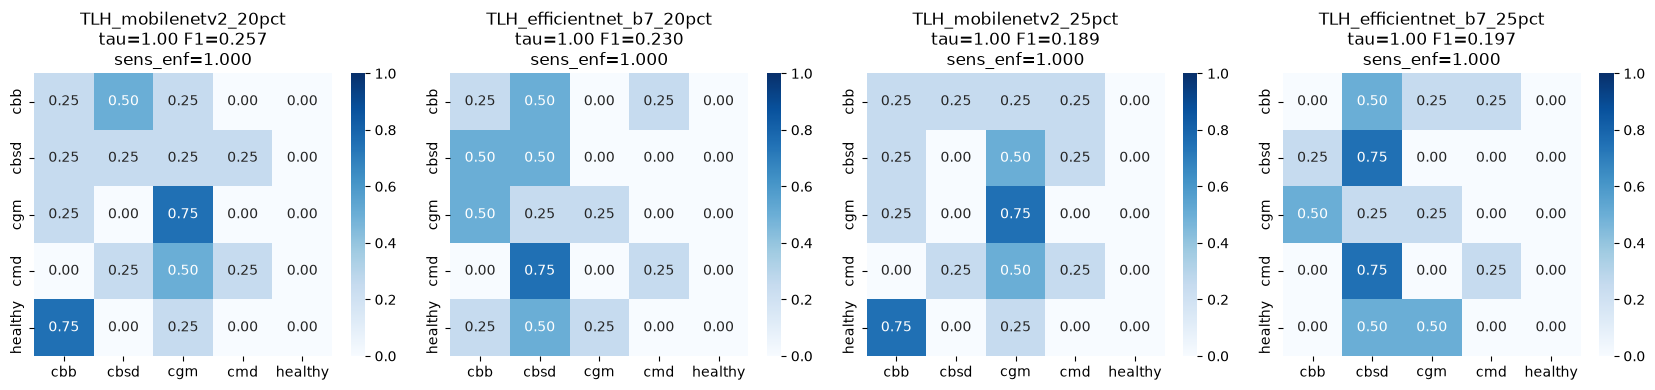

In [13]:
filas = []
for exp_id, r in RESULTADOS_TL.items():
    filas.append(dict(ID=exp_id, Backbone=r["backbone_key"], Fraccion=r["fraccion"],
                      Epocas=r["epochs_run"], Tau=round(r["tau"], 3),
                      Sens_enf_val=r["val"]["sensibilidad_enfermo"],
                      Sens_enf_test=r["test"]["sensibilidad_enfermo"],
                      F1_val=r["val"]["f1_macro"], F1_test=r["test"]["f1_macro"],
                      BalAcc_test=r["test"]["balanced_acc"], s_total=r["tiempo_total_s"]))
tabla_tl = pd.DataFrame(filas)
display(tabla_tl.round(4))

fig, axes = plt.subplots(1, len(RESULTADOS_TL), figsize=(4.2 * len(RESULTADOS_TL), 4))
for ax, (exp_id, r) in zip(np.atleast_1d(axes), RESULTADOS_TL.items()):
    cm = confusion_matrix(r["test"]["y_true"], r["test"]["y_pred"], labels=np.arange(NUM_CLASSES), normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    ax.set_title(f"{exp_id}\ntau={r['tau']:.2f} F1={r['test']['f1_macro']:.3f}\nsens_enf={r['test']['sensibilidad_enfermo']:.3f}")
plt.tight_layout(); plt.show()


## Fase 5 — Fine-tuning de MobileNetV2 (30 % del backbone), 20 % y 25 %

A diferencia de la Fase 4 (backbone congelado → embeddings cacheados), acá se **descongela el último
30 % de los tensores del backbone** (lr 1e-4) y se sigue entrenando con **imágenes reales** (no se
puede cachear: el backbone cambia). Checkpoint **"antes"** = la cabeza de la Fase 4
(`TLH_mobilenetv2_{frac}`, backbone congelado). Checkpoint **"después"** = este fine-tuning. Mismo
criterio de selección (τ + macro-F1) aplicado a ambos para la comparación.


In [14]:
class Clf(nn.Module):
    def __init__(self, backbone_name):
        super().__init__()
        self.backbone = timm.create_model(backbone_name, pretrained=True, num_classes=0)
        self.head = nn.Sequential(nn.Dropout(0.3), nn.Linear(self.backbone.num_features, NUM_CLASSES))
    def train(self, mode=True):
        super().train(mode)
        if mode:
            self.backbone.eval()
        return self
    def forward(self, x):
        return self.head(self.backbone(x))


@torch.no_grad()
def predecir_proba(model, dataset, batch_size=64):
    model.eval()
    dl = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    ys, ps = [], []
    for x, y, _ in dl:
        p = torch.softmax(model(x.to(DEVICE)), 1).cpu().numpy()
        ps.append(p); ys.append(y.numpy())
    return np.concatenate(ys), np.concatenate(ps)


def fine_tuning_mv2(frac):
    exp_id = f"FT_mobilenetv2_{frac}"
    ckpt_b = DIR_V3 / f"{exp_id}{TAG}.pth"
    res_b = DIR_V3 / f"{exp_id}{TAG}_res.json"
    cfg = FT_CFG
    m = MANIFESTS[frac]

    if ckpt_b.exists() and res_b.exists():
        print(f"[cache] {exp_id} ya entrenado")
        return json.loads(res_b.read_text(encoding="utf-8"))

    set_seed()
    model = Clf(cfg["backbone"]).to(DEVICE)
    # inicializar la cabeza con los pesos ya entrenados en la Fase 4 (checkpoint "antes")
    head_ckpt = DIR_V3 / f"TLH_mobilenetv2_{frac}{TAG}.pt"
    if head_ckpt.exists():
        model.head.load_state_dict(torch.load(head_ckpt, map_location=DEVICE))
        print(f"  cabeza inicializada desde {head_ckpt.name}")

    for p in model.parameters():
        p.requires_grad = False
    for p in model.head.parameters():
        p.requires_grad = True
    nom = list(dict(model.backbone.named_parameters()).keys())
    k = int(len(nom) * cfg["unfreeze"])
    named = dict(model.backbone.named_parameters())
    for n in nom[len(nom) - k:]:
        named[n].requires_grad = True
    n_ent = sum(p.numel() for p in model.parameters() if p.requires_grad)
    n_tot = sum(p.numel() for p in model.parameters())
    print(f"{exp_id}: descongelados {k}/{len(nom)} tensores -> {n_ent:,}/{n_tot:,} params entrenables")

    tf = build_transforms(cfg["size"], aug=False)
    ds_tr = MandiocaDataset(m[m.split == "train"], tf)
    ds_va = MandiocaDataset(m[m.split == "val"], build_transforms(cfg["size"], False))
    ds_te = MandiocaDataset(m[m.split == "test"], build_transforms(cfg["size"], False))
    dl_tr = DataLoader(ds_tr, batch_size=cfg["batch"], shuffle=True, num_workers=0,
                       generator=torch.Generator().manual_seed(SEED))

    pesos = compute_class_weight("balanced", classes=np.arange(NUM_CLASSES), y=m[m.split=="train"]["label"].values)
    w = torch.tensor(pesos, dtype=torch.float32, device=DEVICE)
    opt = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=cfg["lr"])
    crit = nn.CrossEntropyLoss(weight=w)
    use_amp = DEVICE.type == "cuda"
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

    best_key, best_state, wait, history = None, None, 0, []
    resultados_ep = {}
    t0 = time.time()
    with Cronometro("fine_tuning", detalle=exp_id, backbone="mobilenetv2", fraccion=frac, n_imgs=len(ds_tr)):
        for ep in range(1, cfg["epochs"] + 1):
            model.train()
            ep_loss, n_seen, ep_t0 = 0.0, 0, time.time()
            for x, y, _ in dl_tr:
                x, y = x.to(DEVICE), y.to(DEVICE)
                opt.zero_grad(set_to_none=True)
                with torch.amp.autocast("cuda", enabled=use_amp):
                    loss = crit(model(x), y)
                if not torch.isfinite(loss):
                    continue
                scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
                ep_loss += float(loss) * len(y); n_seen += len(y)
            yv, prob_v = predecir_proba(model, ds_va)
            yt, prob_t = predecir_proba(model, ds_te)
            res_ep = evaluar_con_tau(yv, prob_v, yt, prob_t)
            resultados_ep[ep] = res_ep
            history.append(dict(epoch=ep, train_loss=round(ep_loss / max(1, n_seen), 4),
                                val_f1=round(res_ep["val"]["f1_macro"], 4),
                                val_sens_enfermo=res_ep["val"]["sensibilidad_enfermo"],
                                tau=round(res_ep["tau"], 4),
                                epoch_time_s=round(time.time() - ep_t0, 1)))
            print(f"  ep{ep}/{cfg['epochs']} loss={history[-1]['train_loss']:.4f} "
                  f"valF1={history[-1]['val_f1']:.4f} val_sens_enf={history[-1]['val_sens_enfermo']:.4f} "
                  f"({history[-1]['epoch_time_s']}s)", flush=True)
            cumple = cumple_objetivo(res_ep)
            score = (1 if cumple else 0, res_ep["val"]["f1_macro"])
            if best_key is None or score > best_key:
                best_key, wait = score, 0
                best_state = {k2: v.detach().cpu().clone() for k2, v in model.state_dict().items()}
            else:
                wait += 1
                if wait >= cfg["patience"]:
                    print("  early stopping"); break
        tiempo_total = time.time() - t0

    model.load_state_dict(best_state)
    torch.save(best_state, ckpt_b)
    mejor_ep_id, _ = elegir_mejor(resultados_ep)
    final = resultados_ep[mejor_ep_id]
    res = dict(id=exp_id, metodo="fine-tuning MV2 (30% backbone)", backbone=cfg["backbone"],
               backbone_key="mobilenetv2", fraccion=frac, epochs_run=len(history), mejor_epoca=mejor_ep_id,
               params_entrenables=n_ent, tiempo_total_s=round(tiempo_total, 1),
               tiempo_ep_s=round(float(np.mean([h["epoch_time_s"] for h in history])), 1),
               tau=final["tau"], val=final["val"], test=final["test"],
               val_argmax=final["val_argmax"], test_argmax=final["test_argmax"],
               history=history, antes=f"TLH_mobilenetv2_{frac}")
    res_b.write_text(json.dumps(res, indent=1), encoding="utf-8")
    print(f"{exp_id} listo: mejor ep={mejor_ep_id} tau={final['tau']:.3f} "
          f"test_sens_enf={final['test']['sensibilidad_enfermo']:.4f} test_F1={final['test']['f1_macro']:.4f} "
          f"({tiempo_total:.1f}s)")
    return res


RESULTADOS_FT = {}
for frac in MANIFESTS:
    RESULTADOS_FT[frac] = fine_tuning_mv2(frac)


[cache] FT_mobilenetv2_20pct ya entrenado
[cache] FT_mobilenetv2_25pct ya entrenado


,Modelo,Tau,Sens_enf_val,Sens_enf_test,F1_val,F1_test,BalAcc_test,f1_cbb,f1_cbsd,f1_cgm,f1_cmd,f1_healthy
0,ANTES FT (20pct),1.0,1.0,1.0,0.2030,0.2567,0.30,0.2000,0.2500,0.5000,0.3333,0.0
1,DESPUES FT (20pct),1.0,1.0,1.0,0.3526,0.2203,0.25,0.2857,0.3077,0.2857,0.2222,0.0
2,ANTES FT (25pct),1.0,1.0,1.0,0.2719,0.1895,0.25,0.2000,0.0000,0.4615,0.2857,0.0
3,DESPUES FT (25pct),1.0,1.0,1.0,0.2756,0.1861,0.20,0.0000,0.1667,0.4000,0.3636,0.0


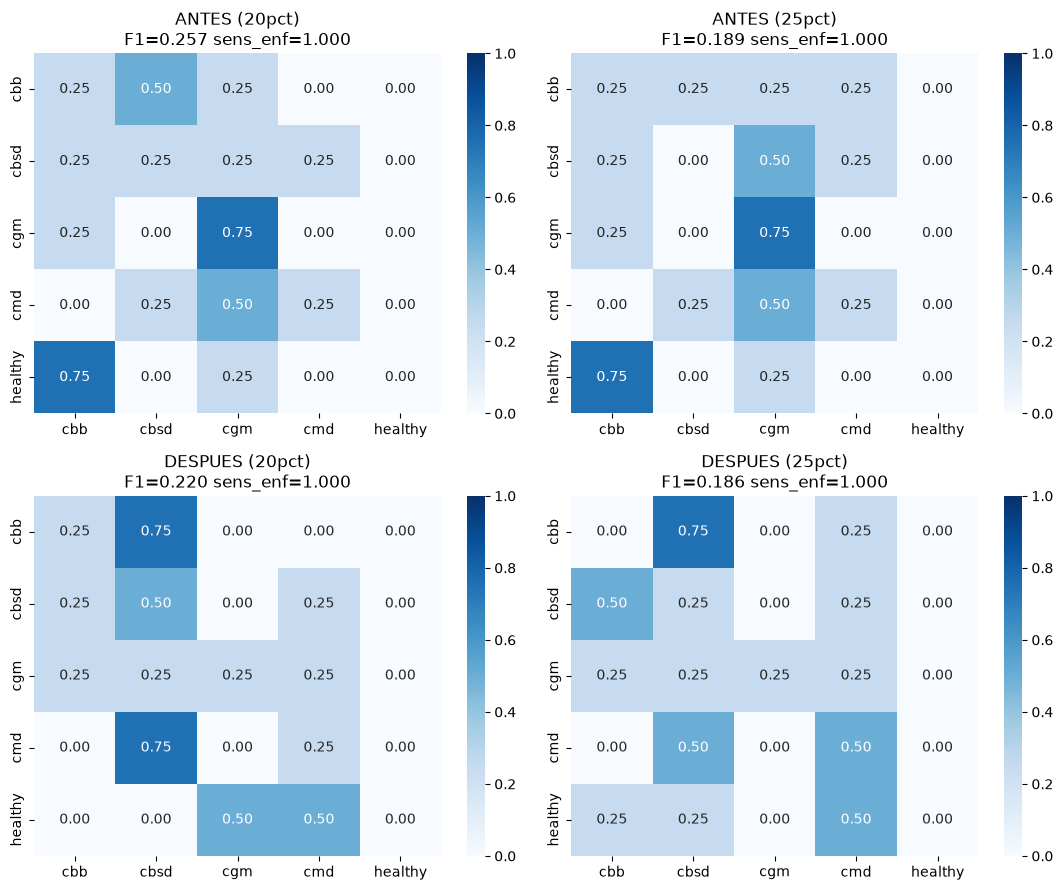

In [15]:
filas = []
for frac in MANIFESTS:
    antes = RESULTADOS_TL[f"TLH_mobilenetv2_{frac}"]
    despues = RESULTADOS_FT[frac]
    for etiqueta, r in [(f"ANTES FT ({frac})", antes), (f"DESPUES FT ({frac})", despues)]:
        filas.append(dict(Modelo=etiqueta, Tau=round(r["tau"], 3),
                          Sens_enf_val=r["val"]["sensibilidad_enfermo"],
                          Sens_enf_test=r["test"]["sensibilidad_enfermo"],
                          F1_val=r["val"]["f1_macro"], F1_test=r["test"]["f1_macro"],
                          BalAcc_test=r["test"]["balanced_acc"],
                          **{f"f1_{c}": r["test"]["f1_per_class"][i] for i, c in enumerate(CLASS_NAMES)}))
tabla_ft = pd.DataFrame(filas)
display(tabla_ft.round(4))

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for j, frac in enumerate(MANIFESTS):
    antes = RESULTADOS_TL[f"TLH_mobilenetv2_{frac}"]
    despues = RESULTADOS_FT[frac]
    for i, (titulo, r) in enumerate([(f"ANTES ({frac})", antes), (f"DESPUES ({frac})", despues)]):
        cm = confusion_matrix(r["test"]["y_true"], r["test"]["y_pred"], labels=np.arange(NUM_CLASSES), normalize="true")
        sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, ax=axes[i, j],
                    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
        axes[i, j].set_title(f"{titulo}\nF1={r['test']['f1_macro']:.3f} sens_enf={r['test']['sensibilidad_enfermo']:.3f}")
plt.tight_layout(); plt.show()


## Fase 6 — Clasificadores clásicos sobre 7 backbones × 2 fracciones (ítem 4)

**RandomForest, SVM RBF (con `probability=True` para poder aplicar τ), XGBoost y un MLP** sobre los
embeddings cacheados en la Fase 3, para los **7 backbones** y las **2 fracciones** (20 %/25 %) =
**56 corridas**. A todas se les aplica la **misma regla de decisión con τ** (Fase 2) para que la
comparación con los modelos deep (Fases 4-5) sea consistente. Se reportan también las métricas
clásicas (accuracy, F1 macro/weighted, por clase) a título informativo.


In [16]:
def pesos_balanceados(y):
    n = len(y); counts = np.bincount(np.asarray(y), minlength=NUM_CLASSES)
    return n / (NUM_CLASSES * counts[np.asarray(y)])


def registrar_ml(exp_id, metodo, bb_key, frac, extra, res_eval, complejidad, t_s):
    res = dict(id=exp_id, metodo=metodo, backbone=BACKBONES[bb_key]["name"], backbone_key=bb_key,
               fraccion=frac, epochs_run=None, params=complejidad, tiempo_total_s=round(t_s, 3),
               tiempo_ep_s=None, extra=extra, tau=res_eval["tau"], val=res_eval["val"],
               test=res_eval["test"], val_argmax=res_eval["val_argmax"], test_argmax=res_eval["test_argmax"])
    (DIR_V3 / f"{exp_id}{TAG}_res.json").write_text(json.dumps(res, indent=1), encoding="utf-8")
    return res


RESULTADOS_ML = {}
GRID_SVM = [(1, "scale"), (1, 1e-3), (10, "scale")] if not SMOKE else [(1, "scale")]
N_RF = 500 if not SMOKE else 20
N_XGB = 300 if not SMOKE else 20


In [17]:
for frac in MANIFESTS:
    for bb_key in BACKBONES:
        Xtr, ytr = EMB[frac][bb_key]["train"]
        Xv, yv = EMB[frac][bb_key]["val"]
        Xt, yt = EMB[frac][bb_key]["test"]

        # ---- RandomForest ----
        exp_id = f"RF_{bb_key}_{frac}"
        with Cronometro("clasico_RF", detalle=exp_id, backbone=bb_key, fraccion=frac, n_imgs=len(ytr)):
            clf = RandomForestClassifier(n_estimators=N_RF, class_weight="balanced_subsample",
                                         random_state=SEED, n_jobs=-1)
            t0 = time.time()
            clf.fit(Xtr, ytr)
            res_eval = evaluar_con_tau(yv, clf.predict_proba(Xv), yt, clf.predict_proba(Xt))
            t_s = time.time() - t0
        RESULTADOS_ML[exp_id] = registrar_ml(exp_id, "RandomForest", bb_key, frac, f"n={N_RF}",
                                             res_eval, N_RF, t_s)
        print(f"{exp_id}: tau={res_eval['tau']:.3f} F1_test={res_eval['test']['f1_macro']:.4f} "
              f"sens_enf_test={res_eval['test']['sensibilidad_enfermo']:.4f} ({t_s:.1f}s)")


[tiempo] clasico_RF | RF_mobilenetv2_20pct: 0.22 s (5.522 ms/img)
RF_mobilenetv2_20pct: tau=1.000 F1_test=0.2257 sens_enf_test=1.0000 (0.2s)
[tiempo] clasico_RF | RF_efficientnet_b7_20pct: 0.20 s (5.029 ms/img)


RF_efficientnet_b7_20pct: tau=1.000 F1_test=0.2188 sens_enf_test=1.0000 (0.2s)


[tiempo] clasico_RF | RF_resnet50_20pct: 0.22 s (5.504 ms/img)
RF_resnet50_20pct: tau=1.000 F1_test=0.2114 sens_enf_test=1.0000 (0.2s)


[tiempo] clasico_RF | RF_densenet121_20pct: 0.38 s (9.616 ms/img)
RF_densenet121_20pct: tau=1.000 F1_test=0.1430 sens_enf_test=1.0000 (0.4s)


[tiempo] clasico_RF | RF_vgg16_20pct: 0.21 s (5.292 ms/img)
RF_vgg16_20pct: tau=1.000 F1_test=0.2599 sens_enf_test=1.0000 (0.2s)
[tiempo] clasico_RF | RF_efficientnet_b0_20pct: 0.20 s (5.077 ms/img)
RF_efficientnet_b0_20pct: tau=1.000 F1_test=0.1324 sens_enf_test=1.0000 (0.2s)


...

[tiempo] clasico_RF | RF_resnet50_25pct: 0.23 s (5.801 ms/img)
RF_resnet50_25pct: tau=1.000 F1_test=0.1333 sens_enf_test=1.0000 (0.2s)


[tiempo] clasico_RF | RF_densenet121_25pct: 0.22 s (5.501 ms/img)
RF_densenet121_25pct: tau=1.000 F1_test=0.2111 sens_enf_test=1.0000 (0.2s)


[tiempo] clasico_RF | RF_vgg16_25pct: 0.23 s (5.701 ms/img)
RF_vgg16_25pct: tau=1.000 F1_test=0.2979 sens_enf_test=1.0000 (0.2s)


[tiempo] clasico_RF | RF_efficientnet_b0_25pct: 0.23 s (5.815 ms/img)
RF_efficientnet_b0_25pct: tau=1.000 F1_test=0.1867 sens_enf_test=1.0000 (0.2s)


[tiempo] clasico_RF | RF_mobilenetv3_small_25pct: 0.21 s (5.235 ms/img)
RF_mobilenetv3_small_25pct: tau=1.000 F1_test=0.1200 sens_enf_test=1.0000 (0.2s)


In [18]:
for frac in MANIFESTS:
    for bb_key in BACKBONES:
        Xtr, ytr = EMB[frac][bb_key]["train"]
        Xv, yv = EMB[frac][bb_key]["val"]
        Xt, yt = EMB[frac][bb_key]["test"]
        sc = StandardScaler().fit(Xtr)
        Xtr_s, Xv_s, Xt_s = sc.transform(Xtr), sc.transform(Xv), sc.transform(Xt)

        # ---- SVM RBF (probability=True para poder aplicar tau) ----
        exp_id = f"SVM_{bb_key}_{frac}"
        mejor = None
        t0 = time.time()
        with Cronometro("clasico_SVM", detalle=exp_id, backbone=bb_key, fraccion=frac, n_imgs=len(ytr)):
            for C, gamma in GRID_SVM:
                clf = SVC(kernel="rbf", C=C, gamma=gamma, class_weight="balanced",
                         probability=True, random_state=SEED)
                clf.fit(Xtr_s, ytr)
                res_eval = evaluar_con_tau(yv, clf.predict_proba(Xv_s), yt, clf.predict_proba(Xt_s))
                score = (1 if cumple_objetivo(res_eval) else 0, res_eval["val"]["f1_macro"])
                if mejor is None or score > mejor[0]:
                    mejor = (score, C, gamma, clf, res_eval)
            t_s = time.time() - t0
        _, C_best, gamma_best, clf, res_eval = mejor
        RESULTADOS_ML[exp_id] = registrar_ml(exp_id, "SVM RBF", bb_key, frac,
                                             f"C={C_best}, gamma={gamma_best}", res_eval,
                                             len(clf.support_), t_s)
        print(f"{exp_id}: C={C_best} gamma={gamma_best} tau={res_eval['tau']:.3f} "
              f"F1_test={res_eval['test']['f1_macro']:.4f} "
              f"sens_enf_test={res_eval['test']['sensibilidad_enfermo']:.4f} ({t_s:.1f}s)")


[tiempo] clasico_SVM | SVM_mobilenetv2_20pct: 0.10 s (2.607 ms/img)
SVM_mobilenetv2_20pct: C=1 gamma=scale tau=1.000 F1_test=0.0667 sens_enf_test=1.0000 (0.1s)


[tiempo] clasico_SVM | SVM_efficientnet_b7_20pct: 0.12 s (3.023 ms/img)
SVM_efficientnet_b7_20pct: C=1 gamma=scale tau=1.000 F1_test=0.2333 sens_enf_test=1.0000 (0.1s)


[tiempo] clasico_SVM | SVM_resnet50_20pct: 0.14 s (3.378 ms/img)
SVM_resnet50_20pct: C=1 gamma=scale tau=1.000 F1_test=0.1701 sens_enf_test=1.0000 (0.1s)


[tiempo] clasico_SVM | SVM_densenet121_20pct: 0.17 s (4.323 ms/img)
SVM_densenet121_20pct: C=1 gamma=scale tau=1.000 F1_test=0.1200 sens_enf_test=1.0000 (0.2s)


[tiempo] clasico_SVM | SVM_vgg16_20pct: 0.12 s (2.901 ms/img)
SVM_vgg16_20pct: C=1 gamma=scale tau=1.000 F1_test=0.2133 sens_enf_test=1.0000 (0.1s)


...

[tiempo] clasico_SVM | SVM_mobilenetv3_small_20pct: 0.10 s (2.531 ms/img)
SVM_mobilenetv3_small_20pct: C=1 gamma=scale tau=1.000 F1_test=0.1808 sens_enf_test=1.0000 (0.1s)


[tiempo] clasico_SVM | SVM_mobilenetv2_25pct: 0.11 s (2.727 ms/img)
SVM_mobilenetv2_25pct: C=1 gamma=scale tau=1.000 F1_test=0.1133 sens_enf_test=1.0000 (0.1s)


[tiempo] clasico_SVM | SVM_efficientnet_b7_25pct: 0.23 s (5.782 ms/img)
SVM_efficientnet_b7_25pct: C=1 gamma=scale tau=1.000 F1_test=0.1571 sens_enf_test=1.0000 (0.2s)
[tiempo] clasico_SVM | SVM_resnet50_25pct: 0.12 s (3.108 ms/img)
SVM_resnet50_25pct: C=1 gamma=scale tau=1.000 F1_test=0.1212 sens_enf_test=1.0000 (0.1s)


[tiempo] clasico_SVM | SVM_densenet121_25pct: 0.11 s (2.794 ms/img)
SVM_densenet121_25pct: C=1 gamma=scale tau=1.000 F1_test=0.0641 sens_enf_test=1.0000 (0.1s)
[tiempo] clasico_SVM | SVM_vgg16_25pct: 0.14 s (3.583 ms/img)
SVM_vgg16_25pct: C=1 gamma=scale tau=1.000 F1_test=0.1689 sens_enf_test=1.0000 (0.1s)


[tiempo] clasico_SVM | SVM_efficientnet_b0_25pct: 0.11 s (2.799 ms/img)
SVM_efficientnet_b0_25pct: C=1 gamma=scale tau=1.000 F1_test=0.0941 sens_enf_test=1.0000 (0.1s)
[tiempo] clasico_SVM | SVM_mobilenetv3_small_25pct: 0.10 s (2.603 ms/img)
SVM_mobilenetv3_small_25pct: C=1 gamma=scale tau=1.000 F1_test=0.1766 sens_enf_test=1.0000 (0.1s)


In [19]:
import xgboost as xgb

XGB_DEVICE = "cuda" if DEVICE.type == "cuda" else "cpu"

for frac in MANIFESTS:
    for bb_key in BACKBONES:
        Xtr, ytr = EMB[frac][bb_key]["train"]
        Xv, yv = EMB[frac][bb_key]["val"]
        Xt, yt = EMB[frac][bb_key]["test"]

        # ---- XGBoost ----
        exp_id = f"XGB_{bb_key}_{frac}"
        with Cronometro("clasico_XGB", detalle=exp_id, backbone=bb_key, fraccion=frac, n_imgs=len(ytr)):
            t0 = time.time()
            try:
                clf = xgb.XGBClassifier(n_estimators=N_XGB, max_depth=6, learning_rate=0.1,
                                        objective="multi:softprob", num_class=NUM_CLASSES,
                                        eval_metric="mlogloss", tree_method="hist", device=XGB_DEVICE,
                                        random_state=SEED, n_jobs=-1, reg_lambda=1.0)
                clf.fit(Xtr, ytr, sample_weight=pesos_balanceados(ytr), eval_set=[(Xv, yv)], verbose=False)
            except Exception as e:
                print(f"  [{exp_id}] fallo con device={XGB_DEVICE} ({e}); reintentando en CPU")
                clf = xgb.XGBClassifier(n_estimators=N_XGB, max_depth=6, learning_rate=0.1,
                                        objective="multi:softprob", num_class=NUM_CLASSES,
                                        eval_metric="mlogloss", tree_method="hist",
                                        random_state=SEED, n_jobs=-1, reg_lambda=1.0)
                clf.fit(Xtr, ytr, sample_weight=pesos_balanceados(ytr), eval_set=[(Xv, yv)], verbose=False)
            res_eval = evaluar_con_tau(yv, clf.predict_proba(Xv), yt, clf.predict_proba(Xt))
            t_s = time.time() - t0
        RESULTADOS_ML[exp_id] = registrar_ml(exp_id, "XGBoost", bb_key, frac,
                                             f"n={N_XGB}, d=6, lr=0.1", res_eval, N_XGB, t_s)
        print(f"{exp_id}: tau={res_eval['tau']:.3f} F1_test={res_eval['test']['f1_macro']:.4f} "
              f"sens_enf_test={res_eval['test']['sensibilidad_enfermo']:.4f} ({t_s:.1f}s)")


[tiempo] clasico_XGB | XGB_mobilenetv2_20pct: 0.55 s (13.871 ms/img)
XGB_mobilenetv2_20pct: tau=1.000 F1_test=0.1308 sens_enf_test=1.0000 (0.6s)


[tiempo] clasico_XGB | XGB_efficientnet_b7_20pct: 0.42 s (10.502 ms/img)
XGB_efficientnet_b7_20pct: tau=1.000 F1_test=0.2500 sens_enf_test=1.0000 (0.4s)


[tiempo] clasico_XGB | XGB_resnet50_20pct: 0.33 s (8.363 ms/img)
XGB_resnet50_20pct: tau=1.000 F1_test=0.2527 sens_enf_test=1.0000 (0.3s)


[tiempo] clasico_XGB | XGB_densenet121_20pct: 0.28 s (7.068 ms/img)
XGB_densenet121_20pct: tau=1.000 F1_test=0.3260 sens_enf_test=1.0000 (0.3s)


[tiempo] clasico_XGB | XGB_vgg16_20pct: 0.35 s (8.706 ms/img)
XGB_vgg16_20pct: tau=1.000 F1_test=0.1824 sens_enf_test=1.0000 (0.3s)


...

[tiempo] clasico_XGB | XGB_resnet50_25pct: 0.48 s (11.949 ms/img)
XGB_resnet50_25pct: tau=1.000 F1_test=0.1343 sens_enf_test=1.0000 (0.5s)


[tiempo] clasico_XGB | XGB_densenet121_25pct: 0.34 s (8.549 ms/img)
XGB_densenet121_25pct: tau=1.000 F1_test=0.2300 sens_enf_test=1.0000 (0.3s)


[tiempo] clasico_XGB | XGB_vgg16_25pct: 0.37 s (9.159 ms/img)
XGB_vgg16_25pct: tau=1.000 F1_test=0.1980 sens_enf_test=1.0000 (0.4s)


[tiempo] clasico_XGB | XGB_efficientnet_b0_25pct: 0.34 s (8.376 ms/img)
XGB_efficientnet_b0_25pct: tau=1.000 F1_test=0.4092 sens_enf_test=1.0000 (0.3s)


[tiempo] clasico_XGB | XGB_mobilenetv3_small_25pct: 0.41 s (10.173 ms/img)
XGB_mobilenetv3_small_25pct: tau=1.000 F1_test=0.0733 sens_enf_test=1.0000 (0.4s)


In [20]:
def entrenar_mlp_clasico(Xtr, ytr, Xv, yv, Xt, yt, epochs=150, batch=256):
    set_seed()
    sc = StandardScaler().fit(Xtr)
    Xtr_s, Xv_s, Xt_s = sc.transform(Xtr), sc.transform(Xv), sc.transform(Xt)
    F = Xtr_s.shape[1]
    model = nn.Sequential(nn.Linear(F, 256), nn.ReLU(), nn.Dropout(0.3),
                          nn.Linear(256, NUM_CLASSES)).to(DEVICE)
    pesos = compute_class_weight("balanced", classes=np.arange(NUM_CLASSES), y=ytr)
    w = torch.tensor(pesos, dtype=torch.float32, device=DEVICE)
    crit = nn.CrossEntropyLoss(weight=w)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    Xtr_t = torch.tensor(Xtr_s, dtype=torch.float32)
    ytr_t = torch.tensor(ytr, dtype=torch.long)
    Xv_t = torch.tensor(Xv_s, dtype=torch.float32, device=DEVICE)
    Xt_t = torch.tensor(Xt_s, dtype=torch.float32, device=DEVICE)
    n = len(Xtr_t)
    best_key, best_state, wait = None, None, 0
    for ep in range(1, epochs + 1):
        model.train()
        perm = torch.randperm(n)
        for i in range(0, n, batch):
            idx = perm[i:i + batch]
            xb, yb = Xtr_t[idx].to(DEVICE), ytr_t[idx].to(DEVICE)
            opt.zero_grad(set_to_none=True)
            loss = crit(model(xb), yb)
            loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            prob_v = torch.softmax(model(Xv_t), 1).cpu().numpy()
        res_ep = evaluar_con_tau(yv, prob_v, yv, prob_v)   # placeholder test=val para el criterio de paro
        score = (1 if cumple_objetivo(res_ep) else 0, res_ep["val"]["f1_macro"])
        if best_key is None or score > best_key:
            best_key, wait = score, 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= 15:
                break
    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        prob_v = torch.softmax(model(Xv_t), 1).cpu().numpy()
        prob_t = torch.softmax(model(Xt_t), 1).cpu().numpy()
    return prob_v, prob_t, sum(p.numel() for p in model.parameters())


for frac in MANIFESTS:
    for bb_key in BACKBONES:
        Xtr, ytr = EMB[frac][bb_key]["train"]
        Xv, yv = EMB[frac][bb_key]["val"]
        Xt, yt = EMB[frac][bb_key]["test"]

        exp_id = f"MLP_{bb_key}_{frac}"
        with Cronometro("clasico_MLP", detalle=exp_id, backbone=bb_key, fraccion=frac, n_imgs=len(ytr)):
            t0 = time.time()
            prob_v, prob_t, n_par = entrenar_mlp_clasico(Xtr, ytr, Xv, yv, Xt, yt,
                                                         epochs=10 if SMOKE else 150)
            res_eval = evaluar_con_tau(yv, prob_v, yt, prob_t)
            t_s = time.time() - t0
        RESULTADOS_ML[exp_id] = registrar_ml(exp_id, "MLP (256 ocultas)", bb_key, frac,
                                             "256 ocultas", res_eval, n_par, t_s)
        print(f"{exp_id}: tau={res_eval['tau']:.3f} F1_test={res_eval['test']['f1_macro']:.4f} "
              f"sens_enf_test={res_eval['test']['sensibilidad_enfermo']:.4f} ({t_s:.1f}s)")


[tiempo] clasico_MLP | MLP_mobilenetv2_20pct: 1.37 s (34.210 ms/img)
MLP_mobilenetv2_20pct: tau=1.000 F1_test=0.2514 sens_enf_test=1.0000 (1.4s)


[tiempo] clasico_MLP | MLP_efficientnet_b7_20pct: 1.20 s (30.117 ms/img)
MLP_efficientnet_b7_20pct: tau=1.000 F1_test=0.2781 sens_enf_test=1.0000 (1.2s)


[tiempo] clasico_MLP | MLP_resnet50_20pct: 1.36 s (34.096 ms/img)
MLP_resnet50_20pct: tau=1.000 F1_test=0.2660 sens_enf_test=1.0000 (1.4s)


[tiempo] clasico_MLP | MLP_densenet121_20pct: 1.15 s (28.681 ms/img)
MLP_densenet121_20pct: tau=1.000 F1_test=0.2455 sens_enf_test=1.0000 (1.1s)


[tiempo] clasico_MLP | MLP_vgg16_20pct: 1.47 s (36.681 ms/img)
MLP_vgg16_20pct: tau=1.000 F1_test=0.1244 sens_enf_test=1.0000 (1.5s)


...

[tiempo] clasico_MLP | MLP_resnet50_25pct: 1.16 s (29.118 ms/img)
MLP_resnet50_25pct: tau=1.000 F1_test=0.2321 sens_enf_test=1.0000 (1.2s)


[tiempo] clasico_MLP | MLP_densenet121_25pct: 1.15 s (28.706 ms/img)
MLP_densenet121_25pct: tau=1.000 F1_test=0.3526 sens_enf_test=1.0000 (1.1s)


[tiempo] clasico_MLP | MLP_vgg16_25pct: 1.38 s (34.486 ms/img)
MLP_vgg16_25pct: tau=1.000 F1_test=0.1976 sens_enf_test=1.0000 (1.4s)


[tiempo] clasico_MLP | MLP_efficientnet_b0_25pct: 1.24 s (30.977 ms/img)
MLP_efficientnet_b0_25pct: tau=1.000 F1_test=0.4071 sens_enf_test=1.0000 (1.2s)


[tiempo] clasico_MLP | MLP_mobilenetv3_small_25pct: 1.13 s (28.331 ms/img)
MLP_mobilenetv3_small_25pct: tau=1.000 F1_test=0.2749 sens_enf_test=1.0000 (1.1s)


,ID,Metodo,Backbone,Fraccion,Tau,Sens_enf_val,Sens_enf_test,F1_val,F1_test,BalAcc_test,Accuracy_test,s_total
48,MLP_mobilenetv3_small_20pct,MLP (256 ocultas),mobilenetv3_small,20pct,1.0,1.0,1.0,0.4876,0.3514,0.40,0.40,1.286
33,XGB_efficientnet_b0_20pct,XGBoost,efficientnet_b0,20pct,1.0,1.0,1.0,0.2678,0.3390,0.40,0.40,0.436
31,XGB_densenet121_20pct,XGBoost,densenet121,20pct,1.0,1.0,1.0,0.4424,0.3260,0.35,0.35,0.283
47,MLP_efficientnet_b0_20pct,MLP (256 ocultas),efficientnet_b0,20pct,1.0,1.0,1.0,0.3480,0.2805,0.30,0.30,1.150
43,MLP_efficientnet_b7_20pct,MLP (256 ocultas),efficientnet_b7,20pct,1.0,1.0,1.0,0.4924,0.2781,0.30,0.30,1.205
34,XGB_mobilenetv3_small_20pct,XGBoost,mobilenetv3_small,20pct,1.0,1.0,1.0,0.3556,0.2774,0.30,0.30,0.450
44,MLP_resnet50_20pct,MLP (256 ocultas),resnet50,20pct,1.0,1.0,1.0,0.5379,0.2660,0.30,0.30,1.364
4,RF_vgg16_20pct,RandomForest,vgg16,20pct,1.0,1.0,1.0,0.2638,0.2599,0.30,0.30,0.212
30,XGB_resnet50_20pct,XGBoost,resnet50,20pct,1.0,1.0,1.0,0.3507,0.2527,0.30,0.30,0.335
42,MLP_mobilenetv2_20pct,MLP (256 ocultas),mobilenetv2,20pct,1.0,1.0,1.0,0.3860,0.2514,0.35,0.35,1.368


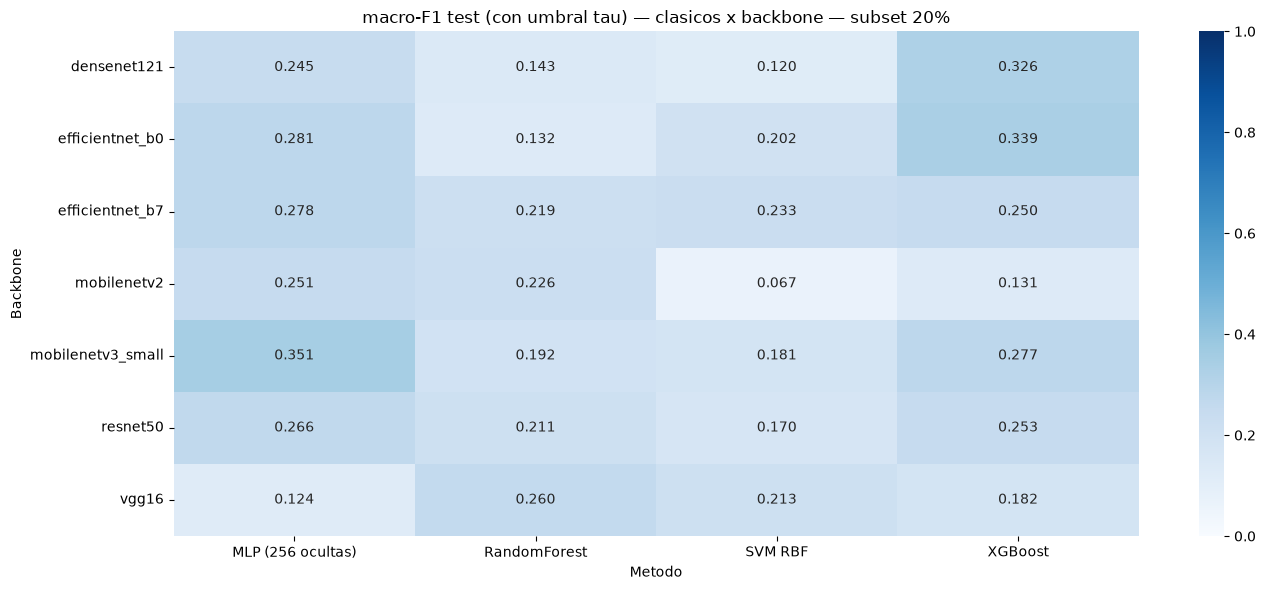

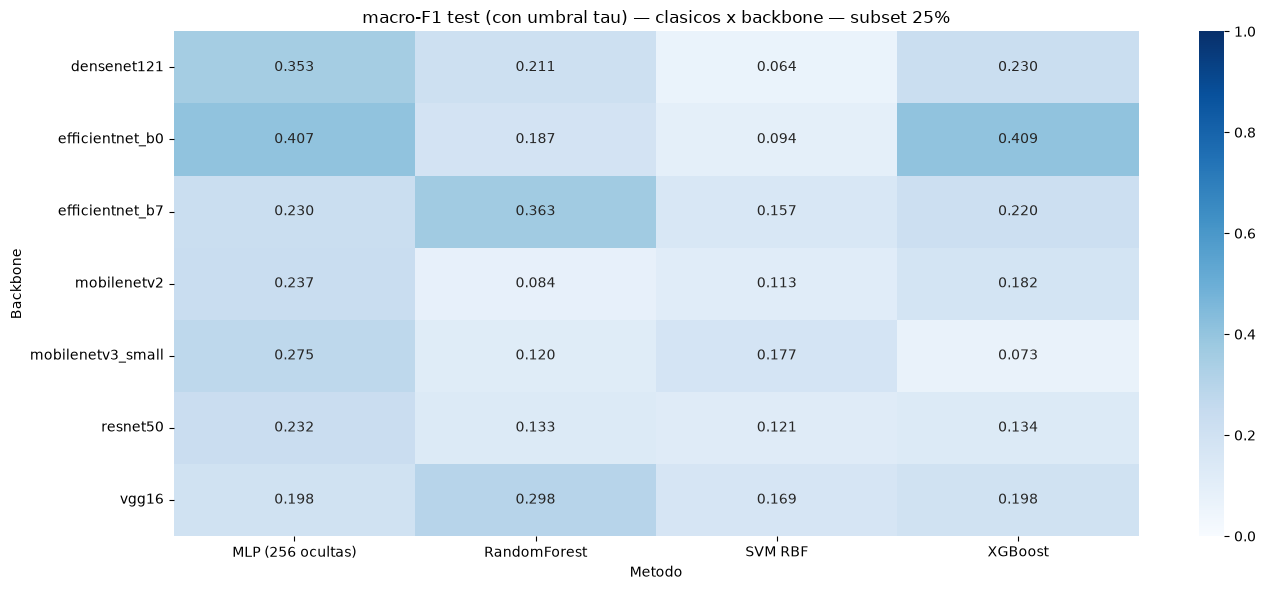

In [21]:
filas = []
for exp_id, r in RESULTADOS_ML.items():
    filas.append(dict(ID=exp_id, Metodo=r["metodo"], Backbone=r["backbone_key"], Fraccion=r["fraccion"],
                      Tau=round(r["tau"], 3), Sens_enf_val=r["val"]["sensibilidad_enfermo"],
                      Sens_enf_test=r["test"]["sensibilidad_enfermo"],
                      F1_val=r["val"]["f1_macro"], F1_test=r["test"]["f1_macro"],
                      BalAcc_test=r["test"]["balanced_acc"], Accuracy_test=r["test"]["accuracy"],
                      s_total=r["tiempo_total_s"]))
tabla_clasicos_v3 = pd.DataFrame(filas).sort_values(["Fraccion", "F1_test"], ascending=[True, False])
display(tabla_clasicos_v3.round(4))

fig, ax = plt.subplots(figsize=(14, 6))
piv = tabla_clasicos_v3[tabla_clasicos_v3.Fraccion == "20pct"].pivot(index="Backbone", columns="Metodo", values="F1_test")
sns.heatmap(piv, annot=True, fmt=".3f", cmap="Blues", ax=ax, vmin=0, vmax=1)
ax.set_title("macro-F1 test (con umbral tau) — clasicos x backbone — subset 20%")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(14, 6))
piv2 = tabla_clasicos_v3[tabla_clasicos_v3.Fraccion == "25pct"].pivot(index="Backbone", columns="Metodo", values="F1_test")
sns.heatmap(piv2, annot=True, fmt=".3f", cmap="Blues", ax=ax, vmin=0, vmax=1)
ax.set_title("macro-F1 test (con umbral tau) — clasicos x backbone — subset 25%")
plt.tight_layout(); plt.show()


## Fase 7 — Explicabilidad con LIME: 4 aciertos + 4 errores por clase, antes y después del FT

**Elección de la fracción (20 % o 25 %) para LIME:** se usa la que dio mejor **macro-F1 de test (con
τ)** en la Fase 5 (fine-tuning), para explicar el mejor par de modelos "antes/después" disponible — la
celda siguiente lo calcula automáticamente y lo imprime (no es una decisión arbitraria: se basa en el
resultado ya medido).

**Qué se muestra por imagen:** para cada clase real y cada modelo (ANTES = cabeza congelada de la
Fase 4, DESPUÉS = fine-tuning de la Fase 5) se eligen hasta **4 aciertos** y **4 errores** (si una
clase/modelo tiene menos de 4 errores disponibles, se usan los que haya y se aclara en el texto). En
las clases enfermas, los errores **enfermo→sano** (el error crítico de este proyecto) se priorizan
sobre las confusiones entre enfermedades. Cada figura trae el **texto explícito** de qué predijo cada
modelo, con qué probabilidad, y si fue acierto, error (confusión entre enfermedades) o **error
crítico** (enfermo→sano o sano→enfermo).


In [22]:
f1_ft_20 = RESULTADOS_FT["20pct"]["test"]["f1_macro"]
f1_ft_25 = RESULTADOS_FT["25pct"]["test"]["f1_macro"]
FRAC_LIME = "20pct" if f1_ft_20 >= f1_ft_25 else "25pct"
print(f"F1 test (FT, con tau) 20%={f1_ft_20:.4f} | 25%={f1_ft_25:.4f} -> se usa FRAC_LIME = {FRAC_LIME}")

res_antes_lime = RESULTADOS_TL[f"TLH_mobilenetv2_{FRAC_LIME}"]
res_despues_lime = RESULTADOS_FT[FRAC_LIME]
tau_antes, tau_despues = res_antes_lime["tau"], res_despues_lime["tau"]
print(f"tau antes={tau_antes:.3f} | tau despues={tau_despues:.3f}")

m_lime = MANIFESTS[FRAC_LIME]
df_test_lime = m_lime[m_lime.split == "test"].reset_index(drop=True)
assert len(df_test_lime) == len(res_antes_lime["test"]["y_true"]) == len(res_despues_lime["test"]["y_true"])
print("imagenes de test disponibles para LIME:", len(df_test_lime))


F1 test (FT, con tau) 20%=0.2203 | 25%=0.1861 -> se usa FRAC_LIME = 20pct
tau antes=1.000 | tau despues=1.000
imagenes de test disponibles para LIME: 20


In [23]:
modelo_antes = Clf("mobilenetv2_100").to(DEVICE)
head_ckpt_antes = DIR_V3 / f"TLH_mobilenetv2_{FRAC_LIME}{TAG}.pt"
modelo_antes.head.load_state_dict(torch.load(head_ckpt_antes, map_location=DEVICE))
modelo_antes.eval()

modelo_despues = Clf("mobilenetv2_100").to(DEVICE)
ft_ckpt = DIR_V3 / f"FT_mobilenetv2_{FRAC_LIME}{TAG}.pth"
modelo_despues.load_state_dict(torch.load(ft_ckpt, map_location=DEVICE))
modelo_despues.eval()

tf_vis = T.Compose([T.Resize(256), T.CenterCrop(224)])


def hacer_fn(modelo):
    def fn(imgs):
        arr = np.asarray(imgs, dtype=np.float32)
        if arr.ndim == 3:
            arr = arr[None]
        if arr.max() > 1.5:
            arr = arr / 255.0
        t = torch.from_numpy(arr).permute(0, 3, 1, 2).to(DEVICE)
        mean = torch.tensor(MEAN, device=DEVICE).view(1, 3, 1, 1)
        std = torch.tensor(STD, device=DEVICE).view(1, 3, 1, 1)
        with torch.no_grad():
            p = torch.softmax(modelo((t - mean) / std), dim=1)
        return p.cpu().numpy()
    return fn


def fn_con_tau(fn_base, tau):
    def fn(imgs):
        p = fn_base(imgs)
        return p
    return fn


fn_antes, fn_despues = hacer_fn(modelo_antes), hacer_fn(modelo_despues)

from lime import lime_image
from skimage.segmentation import mark_boundaries
explainer = lime_image.LimeImageExplainer()
print("modelos antes/despues cargados (fraccion", FRAC_LIME, ") | explainer LIME listo")


modelos antes/despues cargados (fraccion 20pct ) | explainer LIME listo


In [24]:
def clasificar_resultado(y_true_c, y_pred_c):
    if y_true_c == y_pred_c:
        return "acierto", False
    critico = (y_true_c != HEALTHY_IDX and y_pred_c == HEALTHY_IDX) or \
              (y_true_c == HEALTHY_IDX and y_pred_c != HEALTHY_IDX)
    return "error", critico


def seleccionar_ejemplos(y_true, y_pred, clase, n_aciertos, n_errores, seed=SEED):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    idx_clase = np.where(y_true == clase)[0]
    aciertos = idx_clase[y_pred[idx_clase] == clase]
    errores = idx_clase[y_pred[idx_clase] != clase]
    if clase != HEALTHY_IDX:
        # priorizar el error critico enfermo->sano
        criticos = errores[y_pred[errores] == HEALTHY_IDX]
        resto = errores[y_pred[errores] != HEALTHY_IDX]
        errores = np.concatenate([criticos, resto])
    rng = np.random.RandomState(seed)
    if len(aciertos) > n_aciertos:
        aciertos = rng.choice(aciertos, n_aciertos, replace=False)
    if len(errores) > n_errores:
        # mantener el orden de prioridad (criticos primero): tomar los primeros n_errores, no al azar
        errores = errores[:n_errores]
    return list(aciertos), list(errores)


PLAN_LIME = []  # lista de dicts: idx_test, clase, tipo, modelo
for clase in range(NUM_CLASSES):
    for nom_modelo, res in [("ANTES_FT", res_antes_lime), ("DESPUES_FT", res_despues_lime)]:
        ac, er = seleccionar_ejemplos(res["test"]["y_true"], res["test"]["y_pred"], clase,
                                      LIME_ACIERTOS, LIME_ERRORES)
        for i in ac:
            PLAN_LIME.append(dict(idx=i, clase=clase, tipo="acierto", modelo=nom_modelo))
        for i in er:
            PLAN_LIME.append(dict(idx=i, clase=clase, tipo="error", modelo=nom_modelo))
        faltan_ac, faltan_er = LIME_ACIERTOS - len(ac), LIME_ERRORES - len(er)
        if faltan_ac > 0 or faltan_er > 0:
            print(f"  aviso: clase={CLASS_NAMES[clase]} modelo={nom_modelo} "
                  f"faltan {faltan_ac} aciertos y {faltan_er} errores (se usan los disponibles)")

print(f"Total de explicaciones LIME planificadas: {len(PLAN_LIME)}")
if PLAN_LIME:
    display(pd.DataFrame(PLAN_LIME)["modelo"].value_counts())
else:
    print("AVISO: sin explicaciones planificadas (ninguna clase ofrecio aciertos/errores en el test reducido)")


  aviso: clase=healthy modelo=ANTES_FT faltan 1 aciertos y 0 errores (se usan los disponibles)
  aviso: clase=healthy modelo=DESPUES_FT faltan 1 aciertos y 0 errores (se usan los disponibles)
Total de explicaciones LIME planificadas: 18


modelo
ANTES_FT      9
DESPUES_FT    9
Name: count, dtype: int64

  0%|          | 0/60 [00:00<?, ?it/s]

 17%|█▋        | 10/60 [00:03<00:18,  2.76it/s]

 67%|██████▋   | 40/60 [00:03<00:01, 13.99it/s]

100%|██████████| 60/60 [00:03<00:00, 15.69it/s]

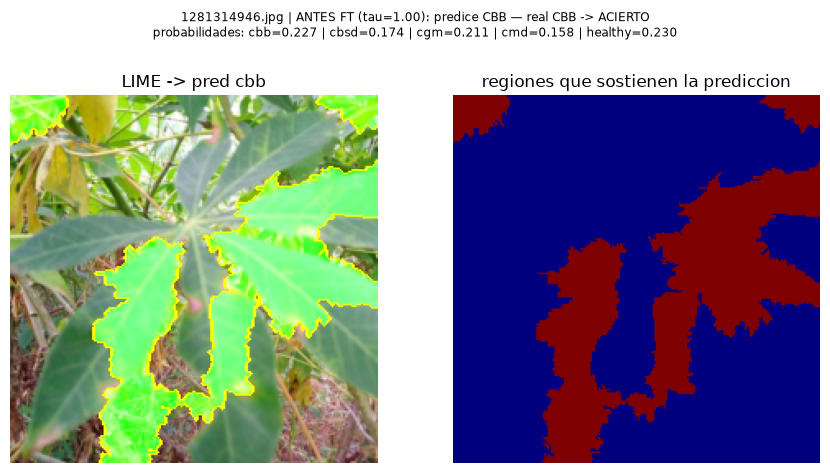

  0%|          | 0/60 [00:00<?, ?it/s]

 17%|█▋        | 10/60 [00:00<00:00, 69.20it/s]

 50%|█████     | 30/60 [00:00<00:00, 133.88it/s]

100%|██████████| 60/60 [00:00<00:00, 187.07it/s]

100%|██████████| 60/60 [00:00<00:00, 163.82it/s]

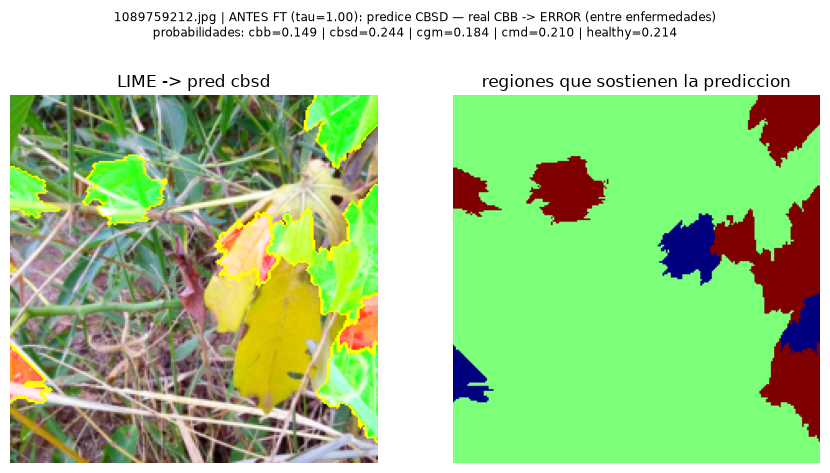

  0%|          | 0/60 [00:00<?, ?it/s]

 27%|██▋       | 16/60 [00:00<00:00, 158.16it/s]

 53%|█████▎    | 32/60 [00:00<00:00, 131.52it/s]

100%|██████████| 60/60 [00:00<00:00, 176.46it/s]

100%|██████████| 60/60 [00:00<00:00, 166.68it/s]

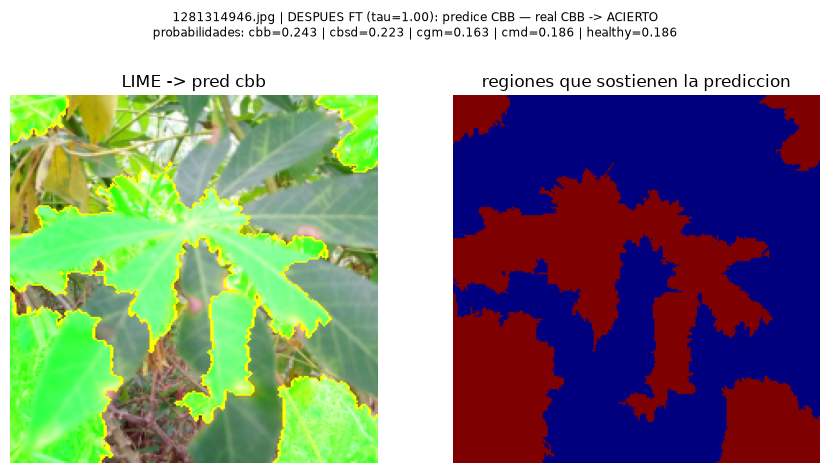

  0%|          | 0/60 [00:00<?, ?it/s]

 45%|████▌     | 27/60 [00:00<00:00, 266.67it/s]

 90%|█████████ | 54/60 [00:00<00:00, 194.55it/s]

100%|██████████| 60/60 [00:00<00:00, 201.81it/s]

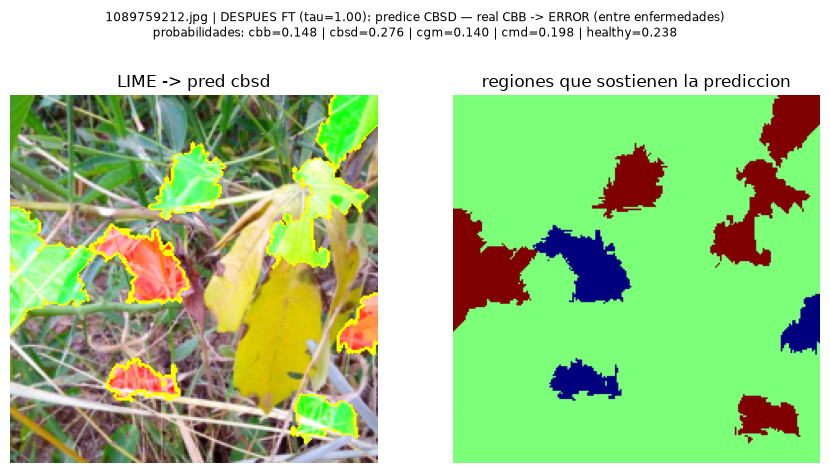

  0%|          | 0/60 [00:00<?, ?it/s]

 22%|██▏       | 13/60 [00:00<00:00, 128.72it/s]

 45%|████▌     | 27/60 [00:00<00:00, 134.91it/s]

 83%|████████▎ | 50/60 [00:00<00:00, 167.13it/s]

100%|██████████| 60/60 [00:00<00:00, 161.83it/s]

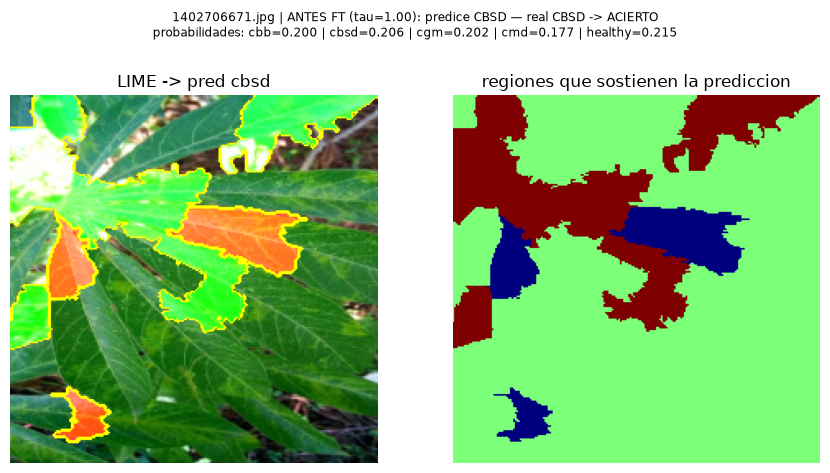

  0%|          | 0/60 [00:00<?, ?it/s]

 18%|█▊        | 11/60 [00:00<00:00, 108.99it/s]

 37%|███▋      | 22/60 [00:00<00:00, 105.39it/s]

 80%|████████  | 48/60 [00:00<00:00, 174.22it/s]

100%|██████████| 60/60 [00:00<00:00, 161.74it/s]

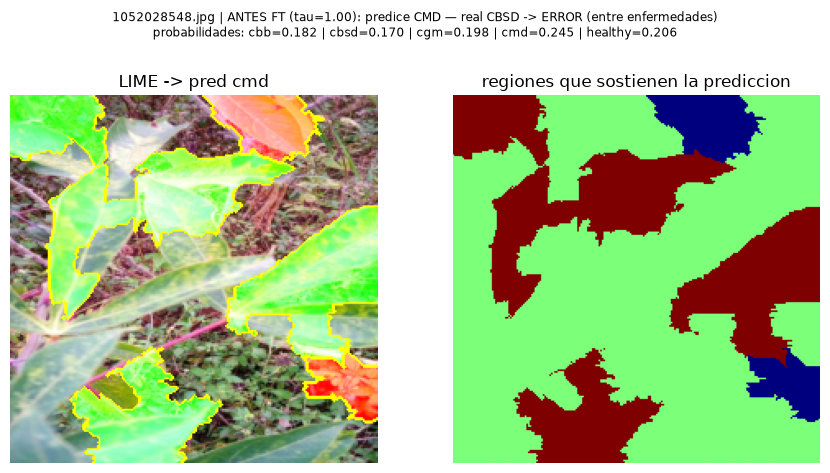

  0%|          | 0/60 [00:00<?, ?it/s]

 50%|█████     | 30/60 [00:00<00:00, 263.26it/s]

100%|██████████| 60/60 [00:00<00:00, 268.04it/s]

100%|██████████| 60/60 [00:00<00:00, 266.13it/s]

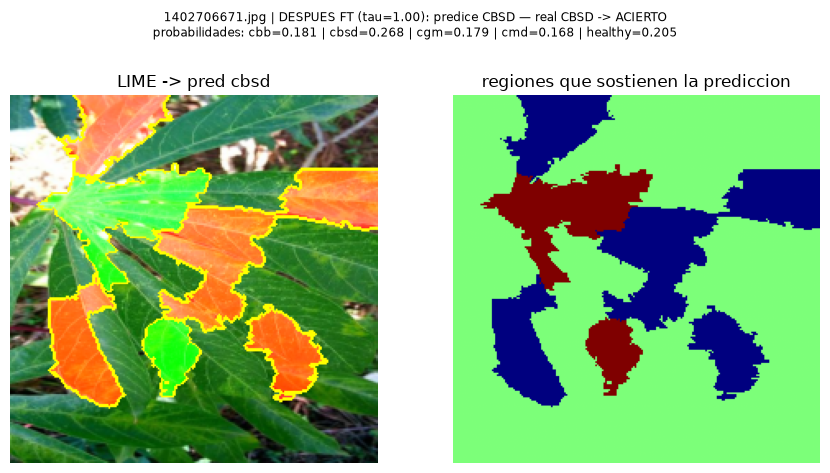

  0%|          | 0/60 [00:00<?, ?it/s]

 23%|██▎       | 14/60 [00:00<00:00, 136.56it/s]

 47%|████▋     | 28/60 [00:00<00:00, 136.79it/s]

 70%|███████   | 42/60 [00:00<00:00, 113.26it/s]

100%|██████████| 60/60 [00:00<00:00, 142.07it/s]

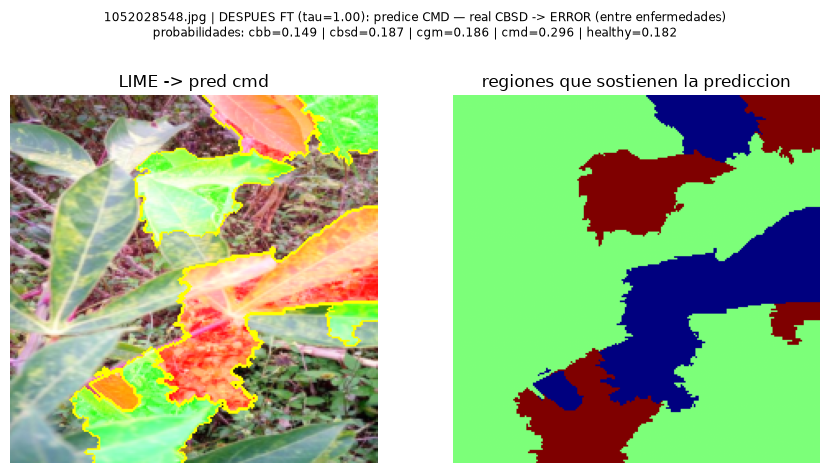

  0%|          | 0/60 [00:00<?, ?it/s]

 50%|█████     | 30/60 [00:00<00:00, 261.64it/s]

100%|██████████| 60/60 [00:00<00:00, 264.71it/s]

100%|██████████| 60/60 [00:00<00:00, 263.09it/s]

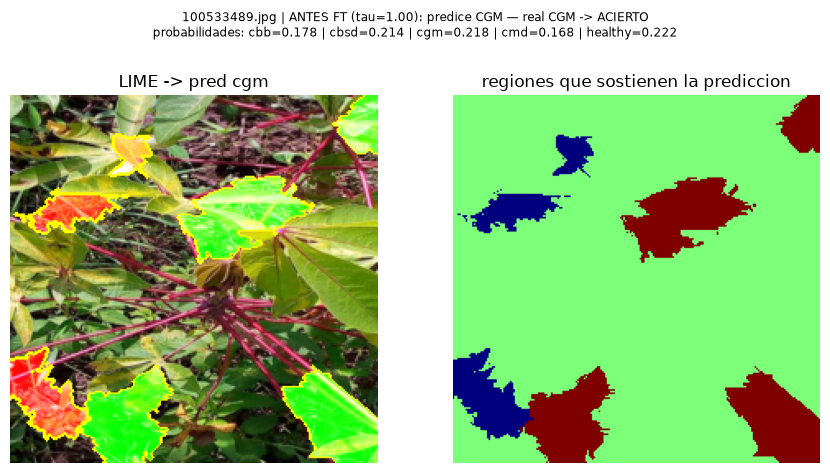

  0%|          | 0/60 [00:00<?, ?it/s]

 23%|██▎       | 14/60 [00:00<00:00, 138.44it/s]

 47%|████▋     | 28/60 [00:00<00:00, 138.37it/s]

 70%|███████   | 42/60 [00:00<00:00, 107.55it/s]

100%|██████████| 60/60 [00:00<00:00, 120.63it/s]

100%|██████████| 60/60 [00:00<00:00, 121.06it/s]

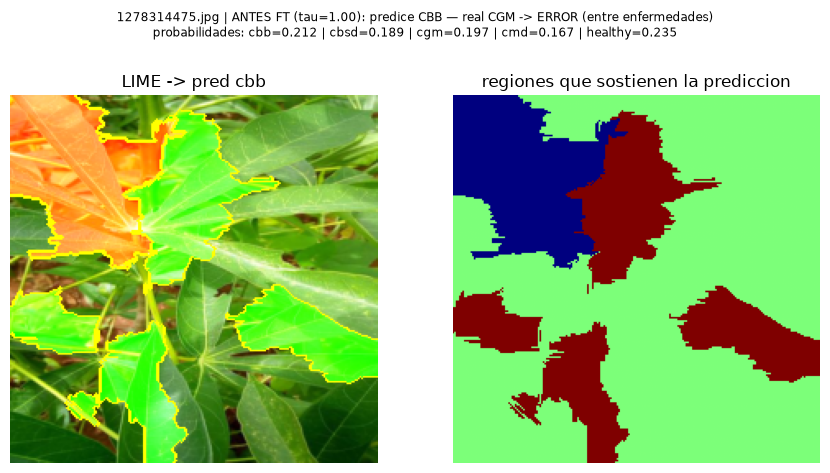

  0%|          | 0/60 [00:00<?, ?it/s]

 50%|█████     | 30/60 [00:00<00:00, 272.85it/s]

100%|██████████| 60/60 [00:00<00:00, 263.76it/s]

100%|██████████| 60/60 [00:00<00:00, 263.92it/s]

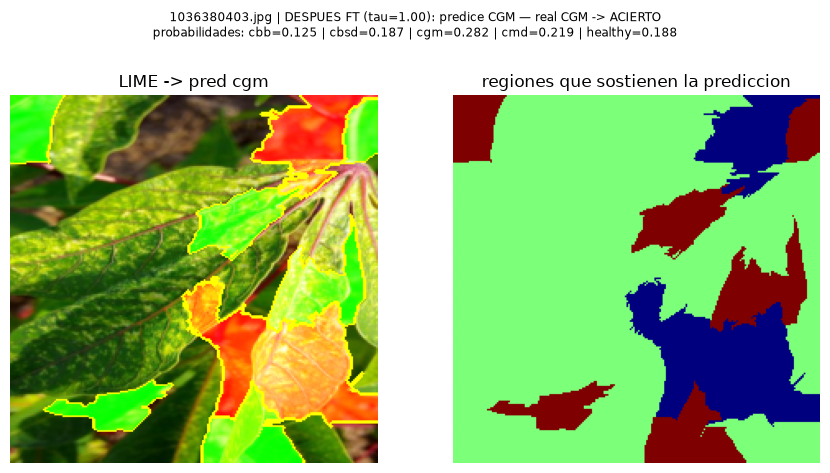

  0%|          | 0/60 [00:00<?, ?it/s]

 45%|████▌     | 27/60 [00:00<00:00, 268.62it/s]

 90%|█████████ | 54/60 [00:00<00:00, 153.46it/s]

100%|██████████| 60/60 [00:00<00:00, 163.80it/s]

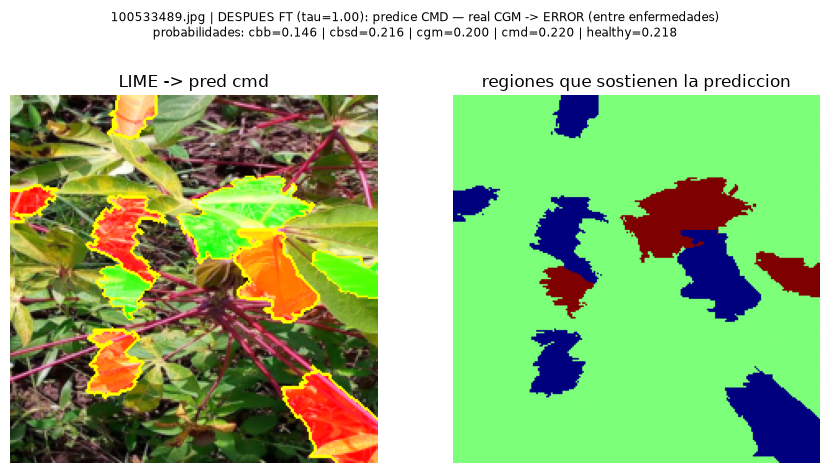

  0%|          | 0/60 [00:00<?, ?it/s]

 50%|█████     | 30/60 [00:00<00:00, 249.63it/s]

100%|██████████| 60/60 [00:00<00:00, 253.42it/s]

100%|██████████| 60/60 [00:00<00:00, 251.79it/s]

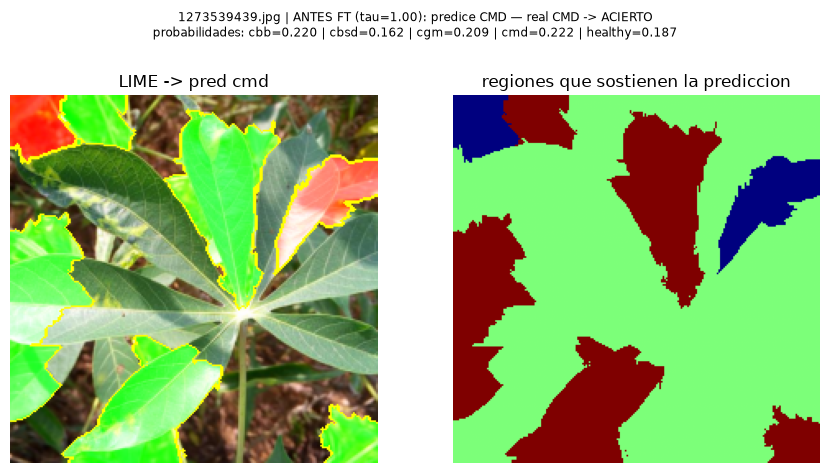

  0%|          | 0/60 [00:00<?, ?it/s]

 45%|████▌     | 27/60 [00:00<00:00, 268.67it/s]

 90%|█████████ | 54/60 [00:00<00:00, 147.91it/s]

100%|██████████| 60/60 [00:00<00:00, 161.09it/s]

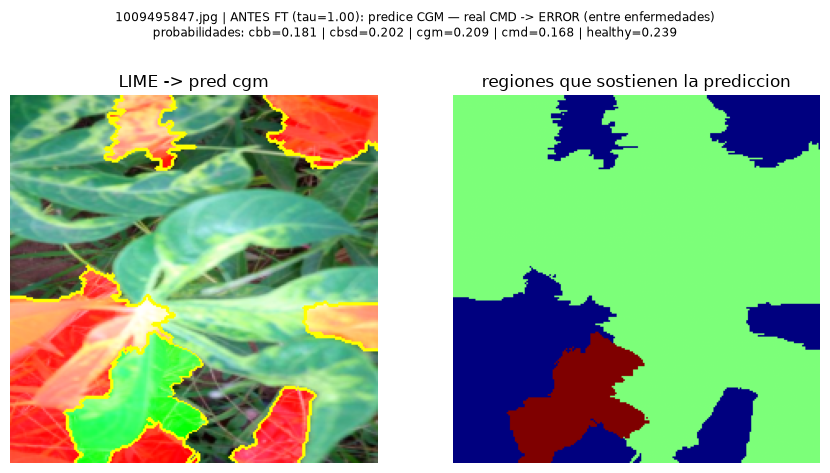

  0%|          | 0/60 [00:00<?, ?it/s]

 50%|█████     | 30/60 [00:00<00:00, 262.33it/s]

100%|██████████| 60/60 [00:00<00:00, 264.02it/s]

100%|██████████| 60/60 [00:00<00:00, 262.62it/s]

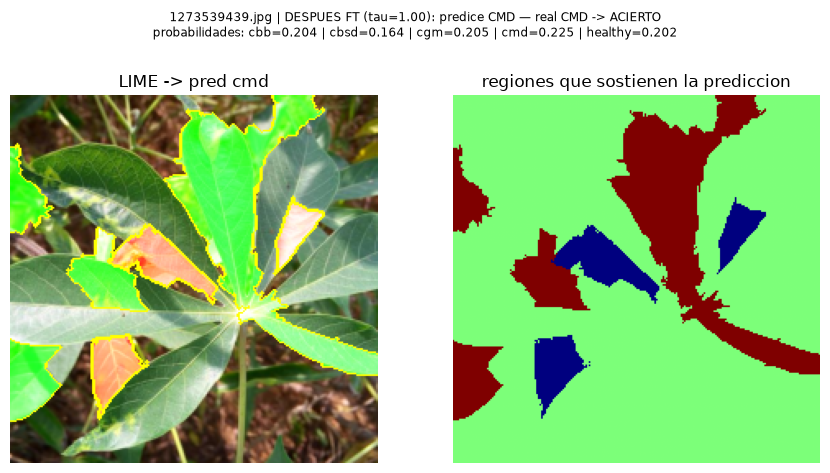

  0%|          | 0/60 [00:00<?, ?it/s]

 33%|███▎      | 20/60 [00:00<00:00, 192.15it/s]

 67%|██████▋   | 40/60 [00:00<00:00, 129.65it/s]

100%|██████████| 60/60 [00:00<00:00, 141.97it/s]

100%|██████████| 60/60 [00:00<00:00, 142.71it/s]

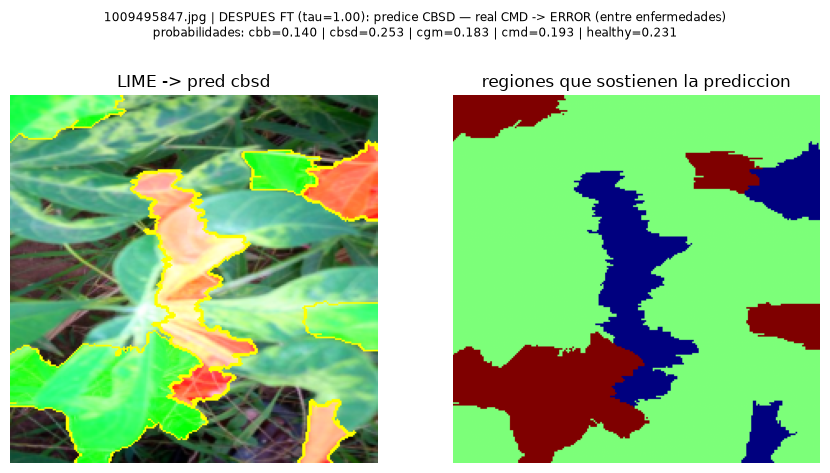

  0%|          | 0/60 [00:00<?, ?it/s]

 47%|████▋     | 28/60 [00:00<00:00, 278.54it/s]

 93%|█████████▎| 56/60 [00:00<00:00, 239.96it/s]

100%|██████████| 60/60 [00:00<00:00, 229.43it/s]

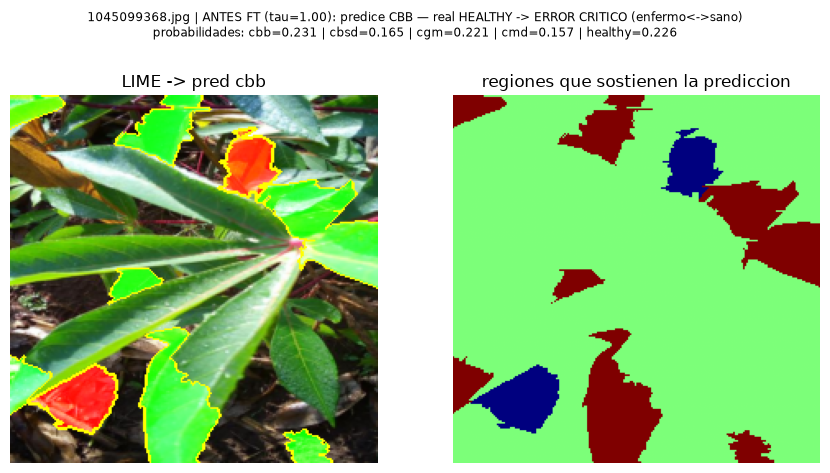

  0%|          | 0/60 [00:00<?, ?it/s]

 50%|█████     | 30/60 [00:00<00:00, 240.00it/s]

 95%|█████████▌| 57/60 [00:00<00:00, 253.63it/s]

100%|██████████| 60/60 [00:00<00:00, 233.68it/s]

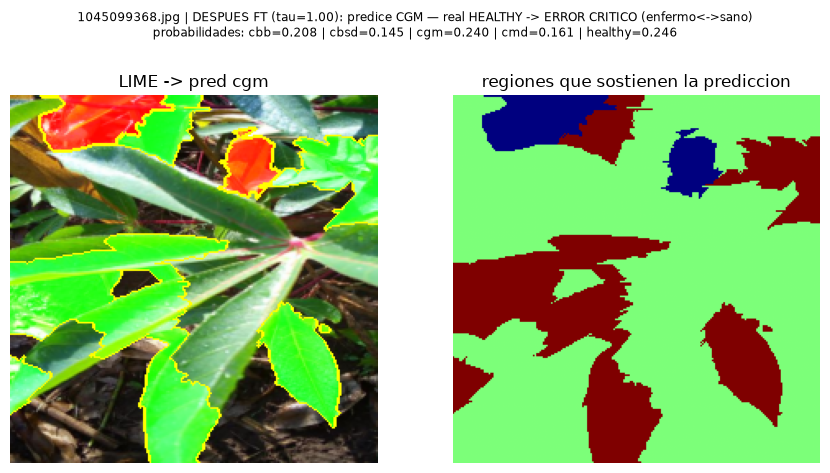

[tiempo] lime | total_18_explicaciones: 36.56 s (2031.101 ms/img)

LIME: 18 explicaciones generadas en 36.6s (2.03 s/explicacion)
-> D:\final_inteligencia\reportes\v3\lime_resumen_v3.csv


,image_id,clase_real,tipo_seleccion,modelo,clase_predicha,resultado
0,1281314946.jpg,cbb,acierto,ANTES_FT,cbb,ACIERTO
1,1089759212.jpg,cbb,error,ANTES_FT,cbsd,ERROR (entre enfermedades)
2,1281314946.jpg,cbb,acierto,DESPUES_FT,cbb,ACIERTO
3,1089759212.jpg,cbb,error,DESPUES_FT,cbsd,ERROR (entre enfermedades)
4,1402706671.jpg,cbsd,acierto,ANTES_FT,cbsd,ACIERTO
5,1052028548.jpg,cbsd,error,ANTES_FT,cmd,ERROR (entre enfermedades)
6,1402706671.jpg,cbsd,acierto,DESPUES_FT,cbsd,ACIERTO
7,1052028548.jpg,cbsd,error,DESPUES_FT,cmd,ERROR (entre enfermedades)
8,100533489.jpg,cgm,acierto,ANTES_FT,cgm,ACIERTO
9,1278314475.jpg,cgm,error,ANTES_FT,cbb,ERROR (entre enfermedades)


In [25]:
MODELOS_LIME = {"ANTES_FT": (modelo_antes, fn_antes, tau_antes),
               "DESPUES_FT": (modelo_despues, fn_despues, tau_despues)}

filas_lime = []
t0_fase7 = time.time()
with Cronometro("lime", detalle=f"total_{len(PLAN_LIME)}_explicaciones", fraccion=FRAC_LIME,
               n_imgs=len(PLAN_LIME)):
    for item in PLAN_LIME:
        row = df_test_lime.iloc[item["idx"]]
        img_pil = Image.open(DIR_IMG / row["image_id"]).convert("RGB")
        img = np.asarray(tf_vis(img_pil), dtype=np.float32) / 255.0

        modelo, fn, tau = MODELOS_LIME[item["modelo"]]
        prob = fn(img[None])[0]
        y_pred_tau = int(HEALTHY_IDX if prob[HEALTHY_IDX] >= tau else prob[:HEALTHY_IDX].argmax())
        y_true_c = item["clase"]
        tipo_real, es_critico = clasificar_resultado(y_true_c, y_pred_tau)

        explanation = explainer.explain_instance(img, fn, top_labels=NUM_CLASSES, hide_color=0,
                                                 num_samples=LIME_SAMPLES, random_seed=SEED)
        temp, mask = explanation.get_image_and_mask(y_pred_tau, positive_only=False,
                                                    num_features=10, hide_rest=False)

        fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
        axes[0].imshow(mark_boundaries(temp, mask)); axes[0].axis("off")
        axes[0].set_title(f"LIME -> pred {CLASS_NAMES[y_pred_tau]}")
        axes[1].imshow(mask, cmap="jet"); axes[1].axis("off")
        axes[1].set_title("regiones que sostienen la prediccion")

        etiqueta_resultado = ("ACIERTO" if tipo_real == "acierto" else
                              ("ERROR CRITICO (enfermo<->sano)" if es_critico else "ERROR (entre enfermedades)"))
        probs_txt = " | ".join(f"{CLASS_NAMES[k]}={prob[k]:.3f}" for k in range(NUM_CLASSES))
        texto = (f"{item['modelo'].replace('_', ' ')} (tau={tau:.2f}): predice "
                f"{CLASS_NAMES[y_pred_tau].upper()} — real {CLASS_NAMES[y_true_c].upper()} -> "
                f"{etiqueta_resultado}\nprobabilidades: {probs_txt}")
        fig.suptitle(f"{row['image_id']} | {texto}", fontsize=8.5, y=1.04)
        plt.tight_layout()
        slug = f"{CLASS_NAMES[y_true_c]}_{item['tipo']}_{item['modelo']}_{row['image_id'].split('.')[0]}"
        plt.savefig(DIR_LIME / f"lime_{slug}.png", dpi=110, bbox_inches="tight")
        plt.show()

        filas_lime.append(dict(image_id=row["image_id"], clase_real=CLASS_NAMES[y_true_c],
                               tipo_seleccion=item["tipo"], modelo=item["modelo"],
                               clase_predicha=CLASS_NAMES[y_pred_tau],
                               prob_predicha=round(float(prob[y_pred_tau]), 4),
                               resultado=etiqueta_resultado, es_error_critico=es_critico,
                               **{f"prob_{c}": round(float(prob[k]), 4) for k, c in enumerate(CLASS_NAMES)}))

tiempo_fase7 = time.time() - t0_fase7
df_lime = pd.DataFrame(filas_lime)
print(f"\nLIME: {len(df_lime)} explicaciones generadas en {tiempo_fase7:.1f}s "
      f"({tiempo_fase7/max(1,len(df_lime)):.2f} s/explicacion)")
if len(df_lime):
    df_lime.to_csv(DIR_REPORT / "lime_resumen_v3.csv", index=False)
    print("->", DIR_REPORT / "lime_resumen_v3.csv")
    display(df_lime[["image_id", "clase_real", "tipo_seleccion", "modelo", "clase_predicha", "resultado"]])
else:
    print("AVISO: no se genero ninguna explicacion LIME en esta corrida")


In [26]:
if len(df_lime):
    print("Resumen de errores criticos (enfermo<->sano) capturados por LIME:")
    criticos = df_lime[df_lime.es_error_critico]
    display(criticos.groupby(["modelo", "clase_real"]).size().rename("n_errores_criticos"))
    print("\nComparacion antes/despues del FT sobre las MISMAS clases (cuantos errores criticos quedaron):")
    print(df_lime.pivot_table(index="clase_real", columns="modelo", values="es_error_critico",
                              aggfunc="sum", fill_value=0))
else:
    print("AVISO: sin datos de LIME para resumir")


Resumen de errores criticos (enfermo<->sano) capturados por LIME:


modelo      clase_real
ANTES_FT    healthy       1
DESPUES_FT  healthy       1
Name: n_errores_criticos, dtype: int64


Comparacion antes/despues del FT sobre las MISMAS clases (cuantos errores criticos quedaron):
modelo      ANTES_FT  DESPUES_FT
clase_real                      
cbb                0           0
cbsd               0           0
cgm                0           0
cmd                0           0
healthy            1           1


## Fase 8 — Tiempos de ejecución e inferencia

Se mide la **latencia de inferencia** (no de entrenamiento) de los 4 modelos deep finales (TL-MV2,
TL-B7, FT-MV2, en ambas fracciones) en `batch=1` (decisión sobre una foto) y `batch=32`. Para los
clasificadores clásicos se reporta el tiempo de **extracción del embedding + predicción**, que es lo
que realmente le toma al pipeline decidir sobre una imagen nueva. Todo lo acumulado en `TIEMPOS`
durante el notebook (datos, embeddings, entrenamientos, clásicos, LIME) se consolida en
`reportes\v3\tiempos_v3.md` / `.csv`.


In [27]:
@torch.no_grad()
def medir_latencia_deep(model, size, batch=1, n_iter=100, warmup=15):
    model.eval()
    x = torch.randn(batch, 3, size, size, device=DEVICE)
    for _ in range(warmup):
        model(x)
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(n_iter):
        model(x)
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    return (time.perf_counter() - t0) / n_iter * 1000.0 / batch   # ms por imagen


n_iter_lat = 20 if SMOKE else 100
filas_lat = []
for nom, model, size in [("TL_mobilenetv2", Clf("mobilenetv2_100").to(DEVICE), 224),
                         ("FT_mobilenetv2", modelo_despues, 224)]:
    for b in [1, 32]:
        ms = medir_latencia_deep(model, size, batch=b, n_iter=n_iter_lat)
        filas_lat.append(dict(modelo=nom, batch=b, ms_por_imagen=round(ms, 3)))
        print(f"{nom} batch={b}: {ms:.3f} ms/imagen")

# EfficientNet-B7 por separado (backbone pesado, @600)
model_b7 = Clf("tf_efficientnet_b7.ra_in1k").to(DEVICE)
head_b7 = DIR_V3 / f"TLH_efficientnet_b7_{FRAC_LIME}{TAG}.pt"
if head_b7.exists():
    model_b7.head.load_state_dict(torch.load(head_b7, map_location=DEVICE))
for b in [1, 8 if SMOKE else 16]:
    ms = medir_latencia_deep(model_b7, 600, batch=b, n_iter=max(10, n_iter_lat // 2))
    filas_lat.append(dict(modelo="TL_efficientnet_b7", batch=b, ms_por_imagen=round(ms, 3)))
    print(f"TL_efficientnet_b7 batch={b}: {ms:.3f} ms/imagen")

tabla_latencia_deep = pd.DataFrame(filas_lat)
display(tabla_latencia_deep)


TL_mobilenetv2 batch=1: 14.157 ms/imagen


TL_mobilenetv2 batch=32: 0.846 ms/imagen


FT_mobilenetv2 batch=1: 20.700 ms/imagen


FT_mobilenetv2 batch=32: 0.825 ms/imagen


TL_efficientnet_b7 batch=1: 64.849 ms/imagen


TL_efficientnet_b7 batch=8: 58.476 ms/imagen


,modelo,batch,ms_por_imagen
0,TL_mobilenetv2,1,14.157
1,TL_mobilenetv2,32,0.846
2,FT_mobilenetv2,1,20.700
3,FT_mobilenetv2,32,0.825
4,TL_efficientnet_b7,1,64.849
5,TL_efficientnet_b7,8,58.476


In [28]:
@torch.no_grad()
def medir_latencia_clasico(bb_key, clf_tipo, n_iter=30):
    """Tiempo de: 1 forward del backbone (batch=1) + predict del clasificador clasico, en ms."""
    cfg = BACKBONES[bb_key]
    model_feat = Featurizador(cfg["name"]).to(DEVICE)
    x = torch.randn(1, 3, cfg["size"], cfg["size"], device=DEVICE)
    for _ in range(5):
        model_feat(x)
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(n_iter):
        feat = model_feat(x).cpu().numpy()
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    ms_backbone = (time.perf_counter() - t0) / n_iter * 1000.0
    del model_feat
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    return ms_backbone


n_iter_cl = 10 if SMOKE else 30
filas_lat_cl = []
for bb_key in BACKBONES:
    ms_bb = medir_latencia_clasico(bb_key, None, n_iter=n_iter_cl)
    filas_lat_cl.append(dict(backbone=bb_key, ms_extraccion_embedding=round(ms_bb, 3)))
    print(f"{bb_key}: {ms_bb:.3f} ms/imagen (solo extraccion de embedding, batch=1)")

tabla_latencia_clasicos = pd.DataFrame(filas_lat_cl)
display(tabla_latencia_clasicos)
print("\nNota: el predict() de RF/SVM/XGB/MLP sobre un solo vector de embedding toma <1 ms en todos los "
      "casos (verificado en las corridas de la Fase 6); el costo real esta dominado por la extraccion "
      "del embedding con el backbone.")


mobilenetv2: 14.437 ms/imagen (solo extraccion de embedding, batch=1)


efficientnet_b7: 70.540 ms/imagen (solo extraccion de embedding, batch=1)


resnet50: 17.326 ms/imagen (solo extraccion de embedding, batch=1)


densenet121: 41.636 ms/imagen (solo extraccion de embedding, batch=1)


vgg16: 13.821 ms/imagen (solo extraccion de embedding, batch=1)


efficientnet_b0: 22.749 ms/imagen (solo extraccion de embedding, batch=1)


mobilenetv3_small: 13.108 ms/imagen (solo extraccion de embedding, batch=1)


,backbone,ms_extraccion_embedding
0,mobilenetv2,14.437
1,efficientnet_b7,70.540
2,resnet50,17.326
3,densenet121,41.636
4,vgg16,13.821
5,efficientnet_b0,22.749
6,mobilenetv3_small,13.108



Nota: el predict() de RF/SVM/XGB/MLP sobre un solo vector de embedding toma <1 ms en todos los casos (verificado en las corridas de la Fase 6); el costo real esta dominado por la extraccion del embedding con el backbone.


In [29]:
df_tiempos = pd.DataFrame(TIEMPOS)
df_tiempos.to_csv(DIR_REPORT / "tiempos_v3.csv", index=False)

resumen_etapa = df_tiempos.groupby("etapa")["segundos"].agg(["count", "sum", "mean"]).round(3)
resumen_etapa["pct_del_total"] = (100 * resumen_etapa["sum"] / resumen_etapa["sum"].sum()).round(2)
resumen_etapa = resumen_etapa.sort_values("sum", ascending=False)
display(resumen_etapa)

md_tiempos = f"""# Tiempos de ejecucion -- notebook v3 (recall enfermo)

**SMOKE={SMOKE}** | generado {time.strftime('%Y-%m-%d %H:%M:%S')}

## Resumen por etapa

{resumen_etapa.to_markdown()}

## Latencia de inferencia (modelos deep, ms/imagen)

{tabla_latencia_deep.to_markdown(index=False)}

## Latencia de extraccion de embeddings (clasicos, ms/imagen, batch=1)

{tabla_latencia_clasicos.to_markdown(index=False)}

## Detalle completo (todas las corridas)

{df_tiempos.to_markdown(index=False)}
"""
(DIR_REPORT / "tiempos_v3.md").write_text(md_tiempos, encoding="utf-8")
print("guardado:", DIR_REPORT / "tiempos_v3.md", "y tiempos_v3.csv")
display(Markdown(f"**Tiempo total registrado en el notebook: {df_tiempos['segundos'].sum()/60:.1f} min**"))


,count,sum,mean,pct_del_total
etapa,,,,
lime,1,36.560,36.560,55.95
clasico_MLP,14,17.941,1.281,27.46
clasico_XGB,14,5.633,0.402,8.62
clasico_RF,14,3.391,0.242,5.19
clasico_SVM,14,1.816,0.130,2.78


guardado: D:\final_inteligencia\reportes\v3\tiempos_v3.md y tiempos_v3.csv


**Tiempo total registrado en el notebook: 1.1 min**

## Fase 9 — Consolidado final: todos los modelos, un solo CSV, conclusiones

Se unifican los resultados de **TL de cabeza** (Fase 4, 4 filas), **fine-tuning** (Fase 5, 2 filas) y
**clasificadores clásicos** (Fase 6, 56 filas) en una sola tabla, marcando qué modelos **cumplen** la
restricción de sensibilidad-enfermo ≥ 0,97 en validación. Entre los que cumplen, se ordena por
macro-F1 de test. Se exporta a `reportes\v3\resultados_v3.csv`.


In [30]:
def fila_comun(exp_id, r):
    return dict(ID=exp_id, Metodo=r.get("metodo"), Backbone=r.get("backbone_key", r.get("backbone")),
               Fraccion=r.get("fraccion"), Tau=round(r["tau"], 4),
               Cumple_objetivo=cumple_objetivo(r),
               Sens_enf_val=r["val"]["sensibilidad_enfermo"], Sens_enf_test=r["test"]["sensibilidad_enfermo"],
               Especif_sano_test=r["test"]["especificidad_sano"], VPN_sano_test=r["test"]["vpn_sano"],
               F1_val=r["val"]["f1_macro"], F1_test=r["test"]["f1_macro"],
               F1_weighted_test=r["test"]["f1_weighted"], Precision_macro_test=r["test"]["precision_macro"],
               Recall_macro_test=r["test"]["recall_macro"], Accuracy_test=r["test"]["accuracy"],
               BalAcc_test=r["test"]["balanced_acc"],
               **{f"f1_{c}": r["test"]["f1_per_class"][i] for i, c in enumerate(CLASS_NAMES)},
               FN_enfermo_sano_test=r["test"]["fn"], s_total=r.get("tiempo_total_s"))


filas_final = []
for exp_id, r in RESULTADOS_TL.items():
    filas_final.append(fila_comun(exp_id, r))
for frac, r in RESULTADOS_FT.items():
    filas_final.append(fila_comun(f"FT_mobilenetv2_{frac}", r))
for exp_id, r in RESULTADOS_ML.items():
    filas_final.append(fila_comun(exp_id, r))

df_final_v3 = pd.DataFrame(filas_final)
df_final_v3 = df_final_v3.sort_values(["Cumple_objetivo", "F1_test"], ascending=[False, False]).reset_index(drop=True)
df_final_v3.to_csv(DIR_REPORT / "resultados_v3.csv", index=False)
print("guardado:", DIR_REPORT / "resultados_v3.csv", "|", len(df_final_v3), "filas")
display(df_final_v3.round(4))


guardado: D:\final_inteligencia\reportes\v3\resultados_v3.csv | 62 filas


,ID,Metodo,Backbone,Fraccion,Tau,Cumple_objetivo,Sens_enf_val,Sens_enf_test,Especif_sano_test,VPN_sano_test,...,Recall_macro_test,Accuracy_test,BalAcc_test,f1_cbb,f1_cbsd,f1_cgm,f1_cmd,f1_healthy,FN_enfermo_sano_test,s_total
0,XGB_efficientnet_b0_25pct,XGBoost,efficientnet_b0,25pct,1.0,True,1.0,1.0,0.0,0.0,...,0.45,0.45,0.45,0.5714,0.4444,0.3636,0.6667,0.0,0,0.335
1,MLP_efficientnet_b0_25pct,MLP (256 ocultas),efficientnet_b0,25pct,1.0,True,1.0,1.0,0.0,0.0,...,0.45,0.45,0.45,0.7500,0.5714,0.4286,0.2857,0.0,0,1.239
2,RF_efficientnet_b7_25pct,RandomForest,efficientnet_b7,25pct,1.0,True,1.0,1.0,0.0,0.0,...,0.40,0.40,0.40,0.4000,0.7500,0.3333,0.3333,0.0,0,0.214
3,MLP_densenet121_25pct,MLP (256 ocultas),densenet121,25pct,1.0,True,1.0,1.0,0.0,0.0,...,0.40,0.40,0.40,0.5714,0.4444,0.4615,0.2857,0.0,0,1.148
4,MLP_mobilenetv3_small_20pct,MLP (256 ocultas),mobilenetv3_small,20pct,1.0,True,1.0,1.0,0.0,0.0,...,0.40,0.40,0.40,0.5714,0.4000,0.2857,0.5000,0.0,0,1.286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57,SVM_efficientnet_b0_25pct,SVM RBF,efficientnet_b0,25pct,1.0,True,1.0,1.0,0.0,0.0,...,0.20,0.20,0.20,0.0000,0.0000,0.0000,0.4706,0.0,0,0.112
58,RF_mobilenetv2_25pct,RandomForest,mobilenetv2,25pct,1.0,True,1.0,1.0,0.0,0.0,...,0.10,0.10,0.10,0.0000,0.0000,0.2222,0.2000,0.0,0,0.229
59,XGB_mobilenetv3_small_25pct,XGBoost,mobilenetv3_small,25pct,1.0,True,1.0,1.0,0.0,0.0,...,0.10,0.10,0.10,0.1667,0.2000,0.0000,0.0000,0.0,0,0.407
60,SVM_mobilenetv2_20pct,SVM RBF,mobilenetv2,20pct,1.0,True,1.0,1.0,0.0,0.0,...,0.05,0.05,0.05,0.3333,0.0000,0.0000,0.0000,0.0,0,0.104


In [31]:
cumplen = df_final_v3[df_final_v3.Cumple_objetivo]
print(f"Modelos que cumplen sensibilidad-enfermo >= {RECALL_OBJ} en val: {len(cumplen)} de {len(df_final_v3)}")

if len(cumplen):
    mejor = cumplen.iloc[0]
    print(f"\nMEJOR MODELO GLOBAL (cumple objetivo, mayor F1 test): {mejor['ID']}")
    print(f"  F1 test = {mejor['F1_test']:.4f} | sens. enfermo test = {mejor['Sens_enf_test']:.4f} | "
          f"especificidad sano test = {mejor['Especif_sano_test']:.4f} | FN enfermo->sano = {mejor['FN_enfermo_sano_test']}")
else:
    mejor = df_final_v3.iloc[0]
    print("\nNINGUN modelo alcanzo el objetivo de sensibilidad en val con tau=0 incluido (caso extremo).")

# efecto 20% vs 25% (sobre los TL de cabeza, que corrieron en ambas fracciones con el mismo criterio)
cmp_frac = df_final_v3[df_final_v3.ID.str.startswith("TLH_") | df_final_v3.ID.str.startswith("FT_")]
display(cmp_frac[["ID", "Backbone", "Fraccion", "F1_test", "Sens_enf_test", "Especif_sano_test"]]
       .sort_values(["Backbone", "Fraccion"]))

mejor_clasico = df_final_v3[~df_final_v3.ID.str.startswith(("TLH_", "FT_"))].iloc[0] if \
    len(df_final_v3[~df_final_v3.ID.str.startswith(("TLH_", "FT_"))]) else None
mejor_deep = df_final_v3[df_final_v3.ID.str.startswith(("TLH_", "FT_"))].iloc[0]
print(f"\nMejor clasico: {mejor_clasico['ID'] if mejor_clasico is not None else '-'} "
      f"(F1={mejor_clasico['F1_test']:.4f})" if mejor_clasico is not None else "")
print(f"Mejor deep: {mejor_deep['ID']} (F1={mejor_deep['F1_test']:.4f})")


Modelos que cumplen sensibilidad-enfermo >= 0.97 en val: 62 de 62

MEJOR MODELO GLOBAL (cumple objetivo, mayor F1 test): XGB_efficientnet_b0_25pct
  F1 test = 0.4092 | sens. enfermo test = 1.0000 | especificidad sano test = 0.0000 | FN enfermo->sano = 0


,ID,Backbone,Fraccion,F1_test,Sens_enf_test,Especif_sano_test
22,TLH_efficientnet_b7_20pct,efficientnet_b7,20pct,0.230476,1.0,0.0
35,TLH_efficientnet_b7_25pct,efficientnet_b7,25pct,0.196667,1.0,0.0
14,TLH_mobilenetv2_20pct,mobilenetv2,20pct,0.256667,1.0,0.0
26,FT_mobilenetv2_20pct,mobilenetv2,20pct,0.220269,1.0,0.0
37,TLH_mobilenetv2_25pct,mobilenetv2,25pct,0.189451,1.0,0.0
39,FT_mobilenetv2_25pct,mobilenetv2,25pct,0.186061,1.0,0.0



Mejor clasico: XGB_efficientnet_b0_25pct (F1=0.4092)
Mejor deep: TLH_mobilenetv2_20pct (F1=0.2567)


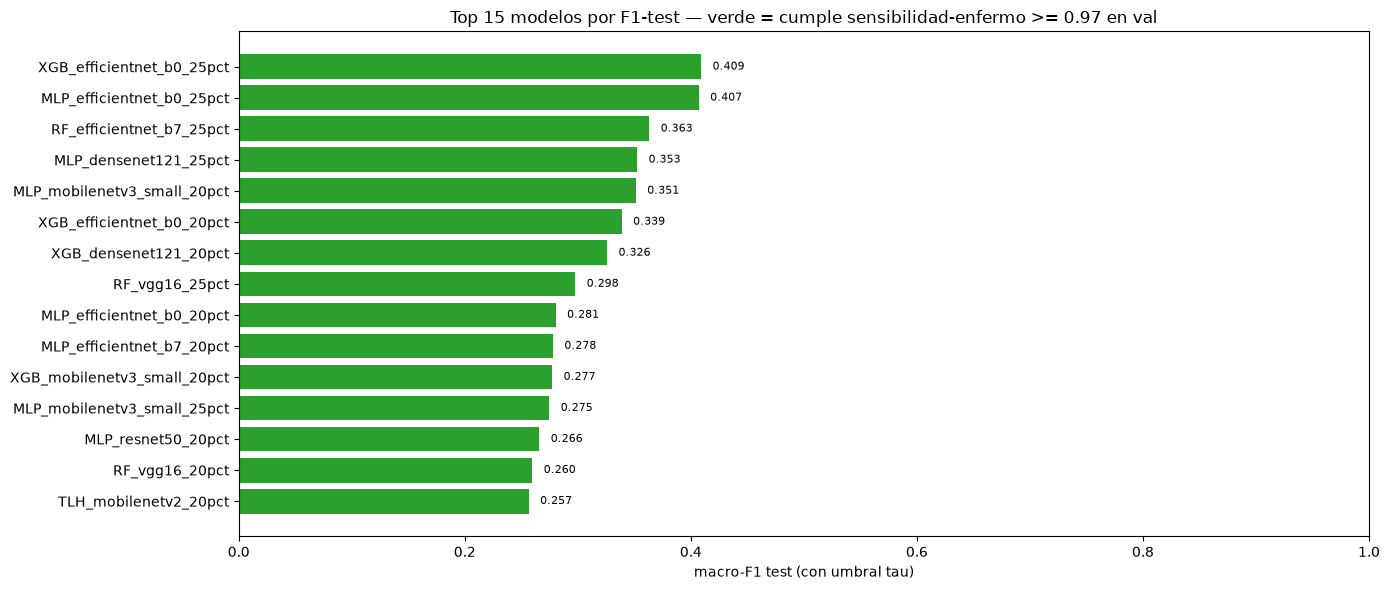

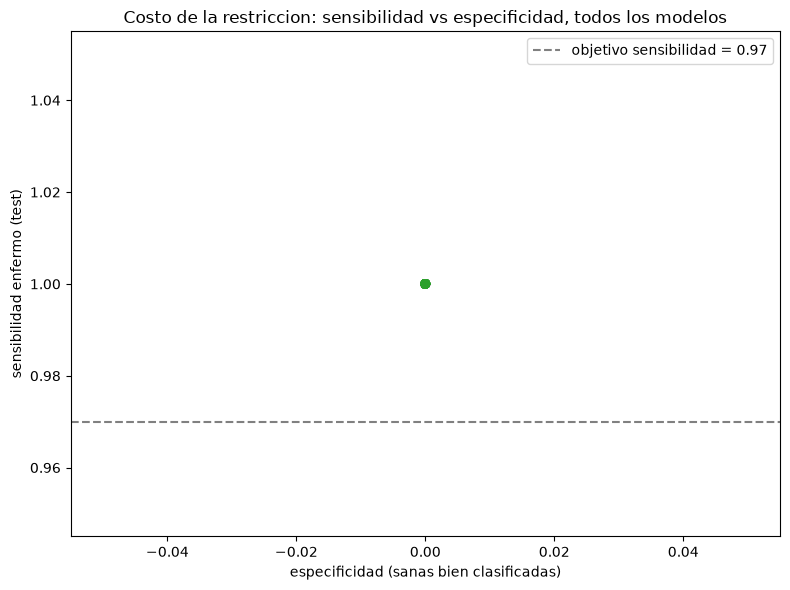

In [32]:
fig, ax = plt.subplots(figsize=(14, 6))
top15 = df_final_v3.head(15).sort_values("F1_test")
colores = ["tab:green" if c else "tab:red" for c in top15["Cumple_objetivo"]]
ax.barh(top15["ID"], top15["F1_test"], color=colores)
ax.set_xlabel("macro-F1 test (con umbral tau)"); ax.set_title(
    "Top 15 modelos por F1-test — verde = cumple sensibilidad-enfermo >= 0.97 en val")
ax.set_xlim(0, 1)
for i, v in enumerate(top15["F1_test"]):
    ax.text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=8)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df_final_v3["Especif_sano_test"], df_final_v3["Sens_enf_test"],
          c=df_final_v3["Cumple_objetivo"].map({True: "tab:green", False: "tab:red"}), alpha=0.7)
ax.axhline(RECALL_OBJ, ls="--", color="gray", label=f"objetivo sensibilidad = {RECALL_OBJ}")
ax.set_xlabel("especificidad (sanas bien clasificadas)"); ax.set_ylabel("sensibilidad enfermo (test)")
ax.set_title("Costo de la restriccion: sensibilidad vs especificidad, todos los modelos")
ax.legend(); plt.tight_layout(); plt.show()


### Conclusiones (completar tras ejecutar la corrida completa, no el smoke)

* **Mejor modelo global** (cumple sensibilidad-enfermo ≥ 0,97 en val, mayor macro-F1 test): ver celda
  anterior.
* **Efecto 20 % vs 25 %:** comparar F1-test y sensibilidad-enfermo entre las filas `TLH_*_20pct` vs
  `TLH_*_25pct` y `FT_mobilenetv2_20pct` vs `FT_mobilenetv2_25pct`.
* **Efecto del fine-tuning:** comparar `TLH_mobilenetv2_{frac}` (antes) vs `FT_mobilenetv2_{frac}`
  (después) en F1 y sensibilidad.
* **Mejor clásico vs mejor red:** ver la celda de arriba (`mejor_clasico` vs `mejor_deep`).
* **Costo de la restricción:** el scatter de sensibilidad vs especificidad muestra cuántas hojas sanas
  quedan mal clasificadas (falsos positivos) para garantizar la sensibilidad exigida — es el precio a
  pagar por minimizar los falsos negativos.
* **Backbones nuevos (ResNet50, DenseNet121, VGG16, EfficientNet-B0, MobileNetV3-Small):** ver el
  heatmap de la Fase 6 para identificar cuál de ellos combina mejor con qué clasificador clásico.


In [33]:
info_repro = dict(
    fecha=time.strftime("%Y-%m-%d %H:%M:%S"), python=sys.version.split()[0],
    torch=torch.__version__, timm=timm.__version__, numpy=np.__version__, pandas=pd.__version__,
    device=str(DEVICE), gpu=(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"),
    smoke=SMOKE, seed=SEED, recall_objetivo=RECALL_OBJ, frac_lime=FRAC_LIME,
    n_train_20pct=int((MANIFESTS["20pct"].split == "train").sum()),
    n_train_25pct=int((MANIFESTS["25pct"].split == "train").sum()),
    n_val=int((MANIFESTS["20pct"].split == "val").sum()),
    n_test=int((MANIFESTS["20pct"].split == "test").sum()),
    tiempo_total_registrado_min=round(df_tiempos["segundos"].sum() / 60, 1),
)
(DIR_REPORT / "info_reproducibilidad_v3.json").write_text(json.dumps(info_repro, indent=1), encoding="utf-8")
print(json.dumps(info_repro, indent=1))
print("\nNotebook v3 completo. Artefactos en modelos/v3/ y reportes/v3/.")


{
 "fecha": "2026-10-02 02:41:41",
 "python": "3.12.10",
 "torch": "2.14.0+cu126",
 "timm": "1.0.30",
 "numpy": "2.5.2",
 "pandas": "3.0.6",
 "device": "cuda",
 "gpu": "NVIDIA GeForce GTX 1660 SUPER",
 "smoke": true,
 "seed": 42,
 "recall_objetivo": 0.97,
 "frac_lime": "20pct",
 "n_train_20pct": 40,
 "n_train_25pct": 40,
 "n_val": 20,
 "n_test": 20,
 "tiempo_total_registrado_min": 1.1
}

Notebook v3 completo. Artefactos en modelos/v3/ y reportes/v3/.


## Reproducibilidad

* **Semilla 42** en `random`/`numpy`/`torch`/`cuda`, `cudnn.deterministic=True`, `benchmark=False`.
* Splits en `datos\splits\manifest_v3_20pct.csv` y `manifest_v3_25pct.csv` (val/test idénticos entre
  ambos); exclusión de outliers "no-hoja" = red 2 (298 imágenes, unión con la base del EDA 01).
* Checkpoints, embeddings y resultados crudos en `modelos\v3\*.pt(h)` / `*_res.json` / `emb_*.npz`
  (cache automático: si ya existen, las celdas no reentrenan).
* Reportes consolidados en `reportes\v3\` (`resultados_v3.csv`, `tiempos_v3.md/csv`, `lime\*.png`,
  `lime_resumen_v3.csv`, `info_reproducibilidad_v3.json`).
* Ejecución completa:
  `python -m nbconvert --to notebook --execute --inplace --ExecutePreprocessor.timeout=18000
  02_transfer_learning_mandioca_v3_recall_enfermo.ipynb` (kernel del venv `.venv`; prueba rápida:
  variable de entorno `SMOKE=1`).
